# KEN PROTOTYPE 1.0 Model

## COMPARE scenarios: Experiment runner
This file can be used to run a simulation multiple times over different scenarios and different random seeds.

In [1]:
%reload_ext autoreload
%autoreload 2
from model.experiment_runner import ExperimentRunner, ScenarioType
from model.experiment_plots import (
    plot_experiment_variable,
    plot_macro_comparison,
    plot_bop_comparison,
    plot_stocks_comparison,
    plot_sectoral_gdp_comparison,
)
from model.analyze_growth_rates import analyze_growth_rates
# Import the LaTeX export module
from model.latex_export import (
    export_growth_rates_to_latex,
    export_detailed_growth_rates_to_latex
)
import matplotlib.pyplot as plt

In [2]:
# See allowed scenario types
ScenarioType

typing.Literal['Baseline', 'Vision_2030', 'Transformation', 'Steady_state']

In [3]:
# Run an experiment with multiple random iterations per scenario
# Set a base_seed to get the same results when re-running the experiment
exp = ExperimentRunner()
# Decide whether to run stochastic runs or single non-stochastic runs:
# Set the stochastic_runs variable to True to run multiple stochastic iterations (stochastic variable: oil exports) per scenario, or to False to run a single non-stochastic iteration per scenario.
# Standard choice, as chosen in the first KEN paper "Transformation dynamics of an energy-rich and water-scarce economy in the Middle East":
# stochastic_runs = False
stochastic_runs = False
if stochastic_runs:
    exp_reports = exp.run(
        scenarios=["Baseline", "Vision_2030",  "Transformation"], # Also include "Steady_state" here if you want to see the behaviour of your model with the steady state calibration scenario.
        iterations=20, 
        base_seed=42,
        parameter_overrides={'Oil_exports_random_fluctuations': True} 
    )
# THIS is the standard run for the current model documentation and paper:
else:
    exp_reports = exp.run(
        scenarios=["Baseline", "Vision_2030", "Transformation"], # Also include "Steady_state" here if you want to see the behaviour of your model with the steady state calibration scenario.
        iterations=1,
        parameter_overrides={'Oil_exports_random_fluctuations': False}
    )

>> Running simulation 1/3 (Baseline, seed=382233)                   v.Y_growth_rate_forecast[t] 0.19050854100449066 time  1
v.Y_growth_rate_forecast[t] 0.26816194169624863 time  2
v.Y_growth_rate_forecast[t] 0.06671226465715482 time  3
v.Y_growth_rate_forecast[t] 0.06730402252102109 time  4
v.Y_growth_rate_forecast[t] 0.06445246467464141 time  5
v.Y_growth_rate_forecast[t] 0.06449069413624986 time  6
v.Y_growth_rate_forecast[t] 0.07011455342794724 time  7
v.Y_growth_rate_forecast[t] 0.06754671737440383 time  8
v.Y_growth_rate_forecast[t] 0.0639284004255894 time  9
v.Y_growth_rate_forecast[t] 0.06650227574060281 time  10
v.Y_growth_rate_forecast[t] 0.0668612638605465 time  11
v.Y_growth_rate_forecast[t] 0.06315805148065798 time  12
v.Y_growth_rate_forecast[t] 0.05830403775626075 time  13
v.Y_growth_rate_forecast[t] 0.05222539814090548 time  14
v.Y_growth_rate_forecast[t] 0.04942820783235637 time  15
v.Y_growth_rate_forecast[t] 0.04720379055907627 time  16
v.Y_growth_rate_forecast[t] 0.0

## Macroeconomic outputs comparison: Tables

In [4]:
summary_df = analyze_growth_rates(exp_reports)
# Export the summary table to LaTeX
export_growth_rates_to_latex(summary_df)

# Export detailed growth rates by variable
export_detailed_growth_rates_to_latex(
    exp_reports,
    variables=['Y', 'C', 'I_total', 'EX', 'IM', 'P', 'Gov_exp', 'YD_wage']
)

GROWTH RATE COMPARISON ACROSS SCENARIOS

BASELINE SCENARIO:
--------------------------------------------------------------------------------
  Empirical GDP growth rate 2013-2023: 2.66%
  Model GDP growth (geometric mean): 2.66%
  Model GDP growth (arithmetic mean): 2.68%
  GDP start (billion SAR): 3.32
  GDP end (billion SAR): 9.49
  Total growth over period: 186.08%

VISION_2030 SCENARIO:
--------------------------------------------------------------------------------
  Empirical GDP growth rate 2013-2023: 2.66%
  Model GDP growth (geometric mean): 3.37%
  Model GDP growth (arithmetic mean): 3.38%
  GDP start (billion SAR): 3.39
  GDP end (billion SAR): 12.74
  Total growth over period: 276.36%

TRANSFORMATION SCENARIO:
--------------------------------------------------------------------------------
  Empirical GDP growth rate 2013-2023: 2.66%
  Model GDP growth (geometric mean): 3.60%
  Model GDP growth (arithmetic mean): 3.61%
  GDP start (billion SAR): 3.34
  GDP end (billion SAR)

'\\begin{longtable}{lrrr}\n\\caption{Detailed Growth Rates by Variable and Scenario, in \\%} \\label{tab:detailed_growth} \\\\\n\\toprule\nVariable & Baseline & Vision 2030 & Transformation \\\\\n\\midrule\n\\endfirsthead\n\\caption[]{Detailed Growth Rates by Variable and Scenario, in \\%} \\\\\n\\toprule\nVariable & Baseline & Vision 2030 & Transformation \\\\\n\\midrule\n\\endhead\n\\midrule\n\\multicolumn{4}{r}{Continued on next page} \\\\\n\\midrule\n\\endfoot\n\\bottomrule\n\\endlastfoot\nOutput (GDP, Y) & 2.66 & 3.37 & 3.60 \\\\\nConsumption (C) & 3.01 & 3.84 & 3.72 \\\\\nInvestment (I) total & 2.74 & 4.72 & 4.86 \\\\\nExports (EX) & 2.47 & 2.09 & 3.75 \\\\\nImports (IM) & 3.72 & 4.54 & 5.17 \\\\\nProfits (P) & 1.61 & 2.22 & 2.46 \\\\\nGov. expenditures & 3.95 & 3.60 & 3.23 \\\\\nDisposable wage income (YD wage) & 3.93 & 4.62 & 4.60 \\\\\n\\end{longtable}\n'

## Macroeconomic outcomes comparison: Plots

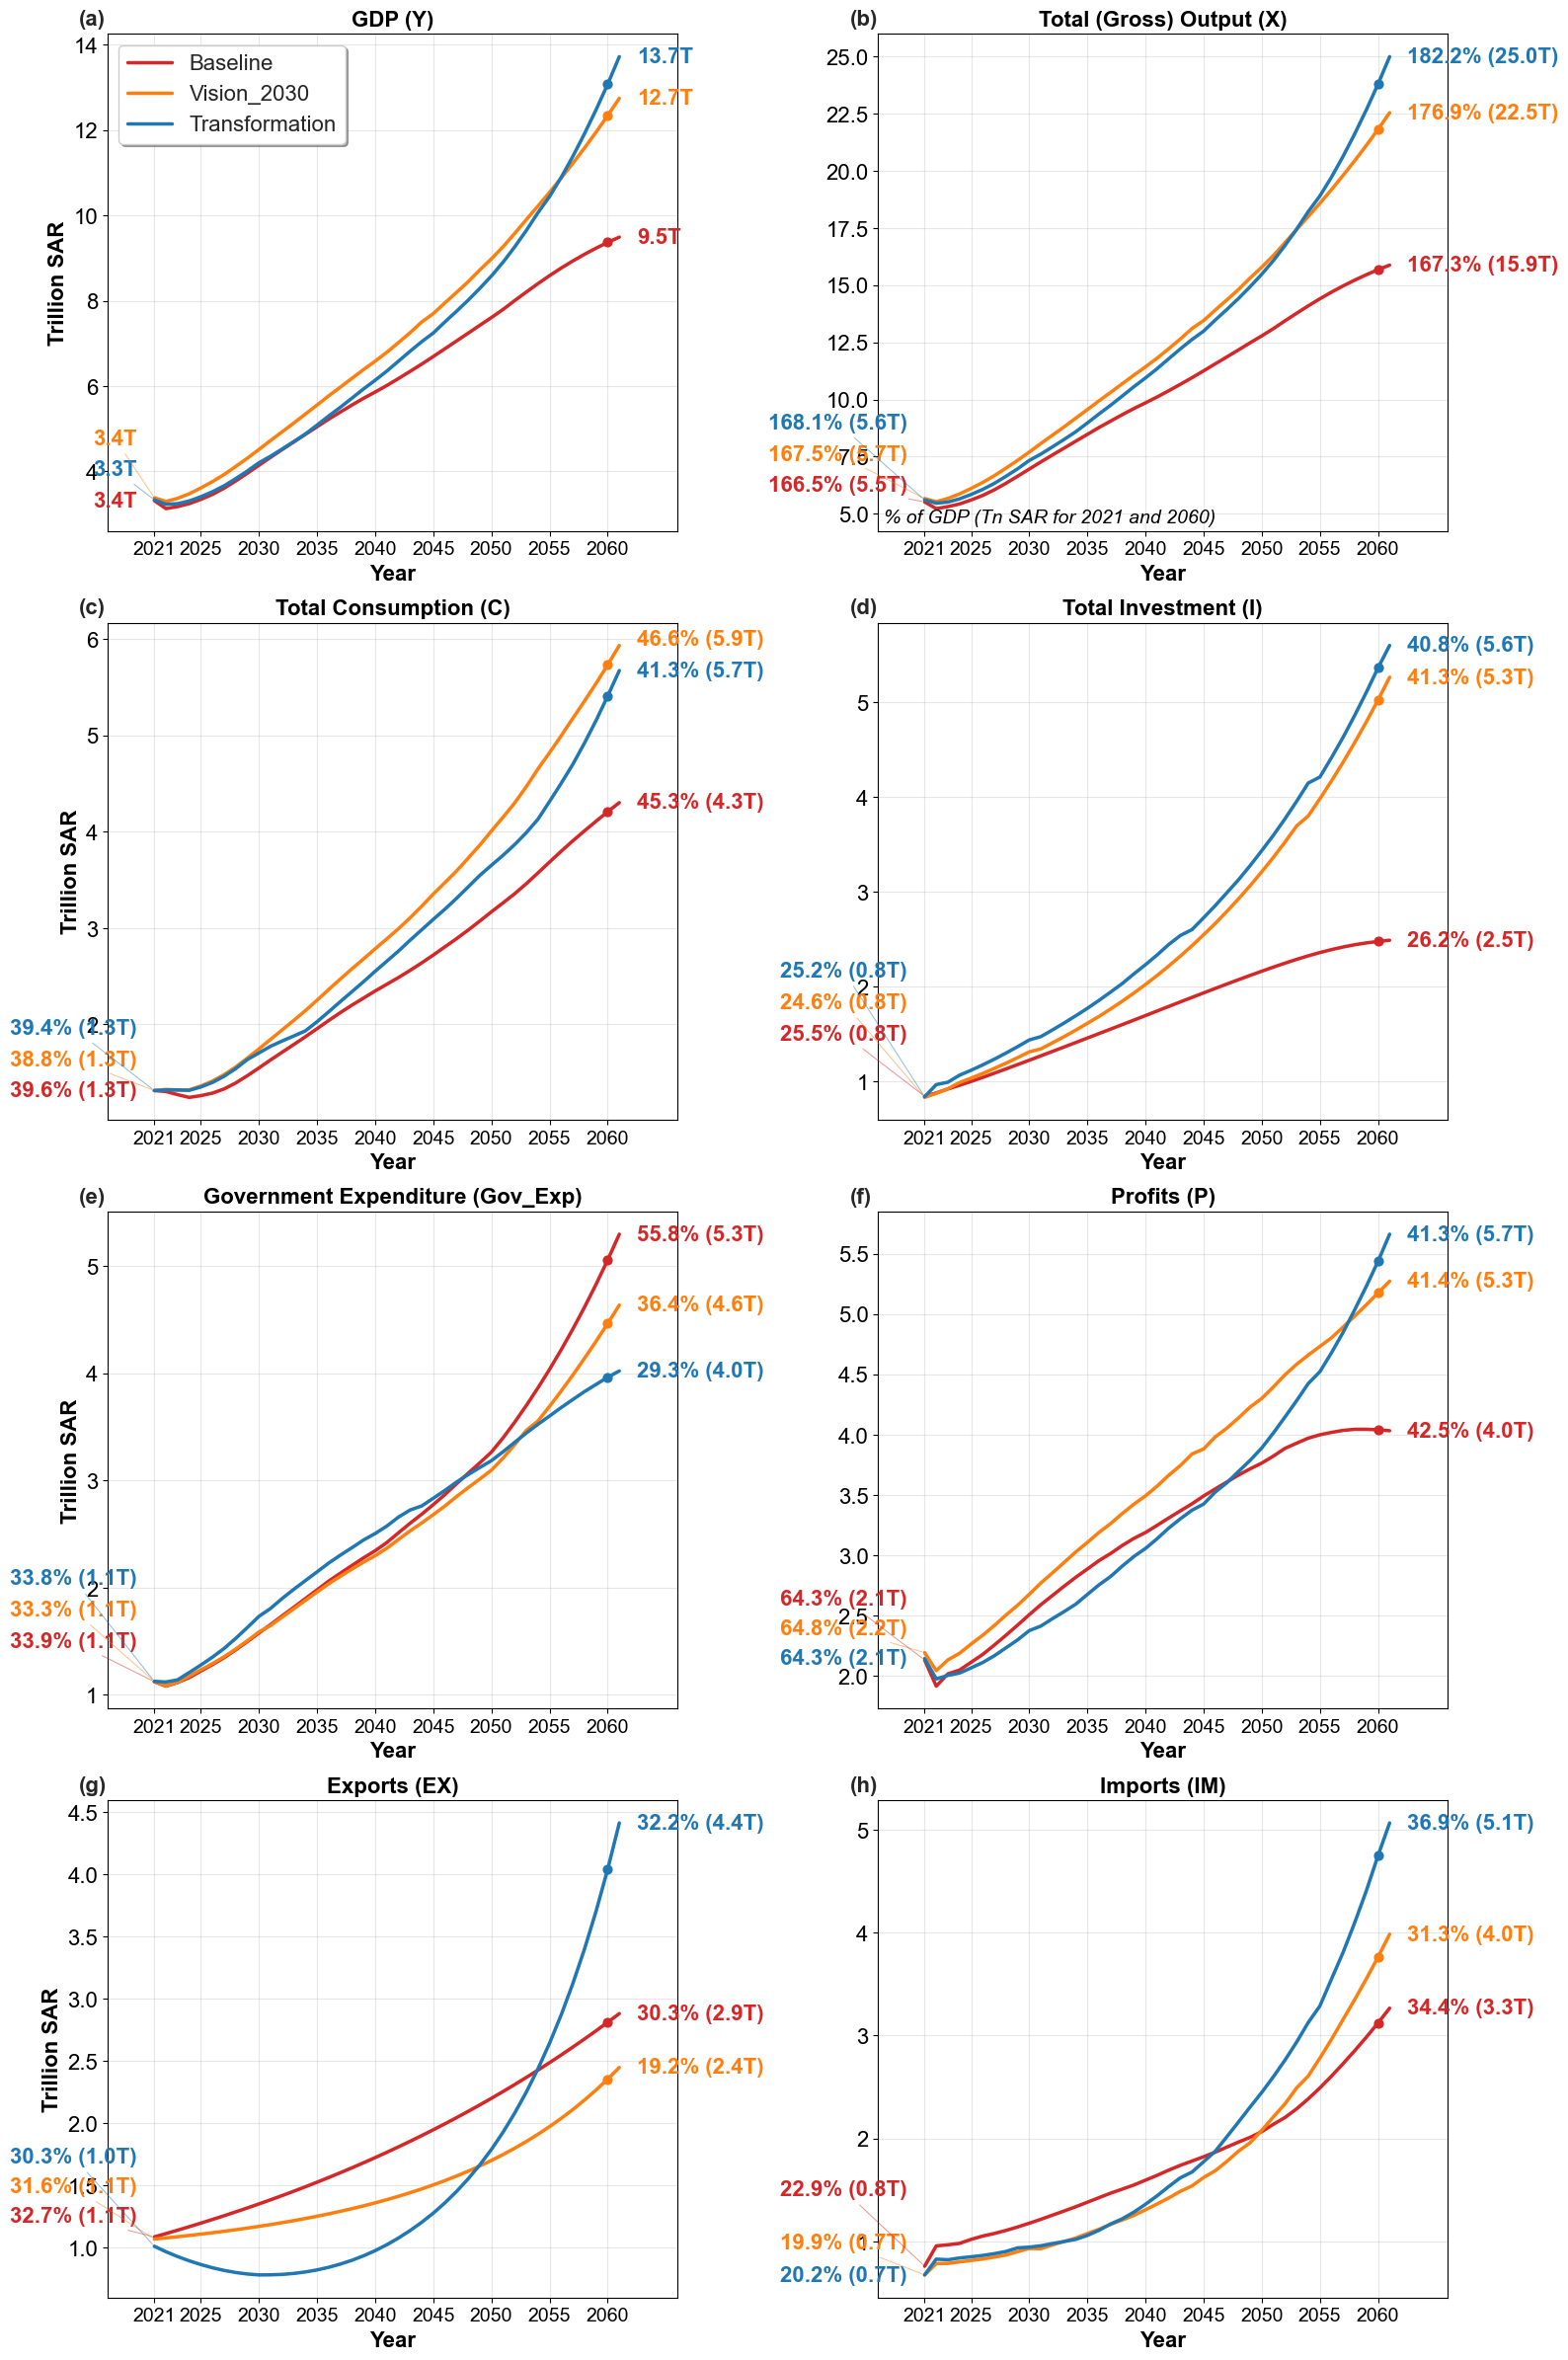

In [5]:
# Plotting average results per scenario
fig, axs = plt.subplots(4, 2, figsize=(16, 24))
axs = axs.flatten()

vars_to_plot = [
    ('Y', 'GDP (Y)', 'Trillion SAR'),
    ('X', "Total (Gross) Output (X)", 'Trillion SAR'),
    ('C', 'Total Consumption (C)', 'Trillion SAR'),
    ('I_total', 'Total Investment (I)', 'Trillion SAR'),
    ('Gov_exp', 'Government Expenditure (Gov_Exp)', 'Trillion SAR'),
    ('P',"Profits (P)", 'Trillion SAR'),
    ('EX', "Exports (EX)", 'Trillion SAR'),
    ('IM', "Imports (IM)", 'Trillion SAR')
]

for plot_idx, (ax, (var_name, var_label, unit)) in enumerate(zip(axs, vars_to_plot)):
    
    # Legend ONLY on the first plot (index 0)
    display_legend = True if plot_idx == 0 else False
    
    # Text annotation ONLY on the second plot (index 1)
    display_annotation_text = True if plot_idx == 1 else False
    
    plot_experiment_variable(
        reports=exp_reports, 
        variable_name=var_name, 
        variable_label=var_label, 
        unit=unit,
        ax=ax,
        show_legend=display_legend,
        show_annotation_caption=display_annotation_text
    )

for _i, _ax in enumerate(axs):
    _ax.text(-0.05, 1.05, f"({chr(ord('a') + _i)})", transform=_ax.transAxes,
             fontsize=16, fontweight='bold', va='top')


plt.tight_layout()

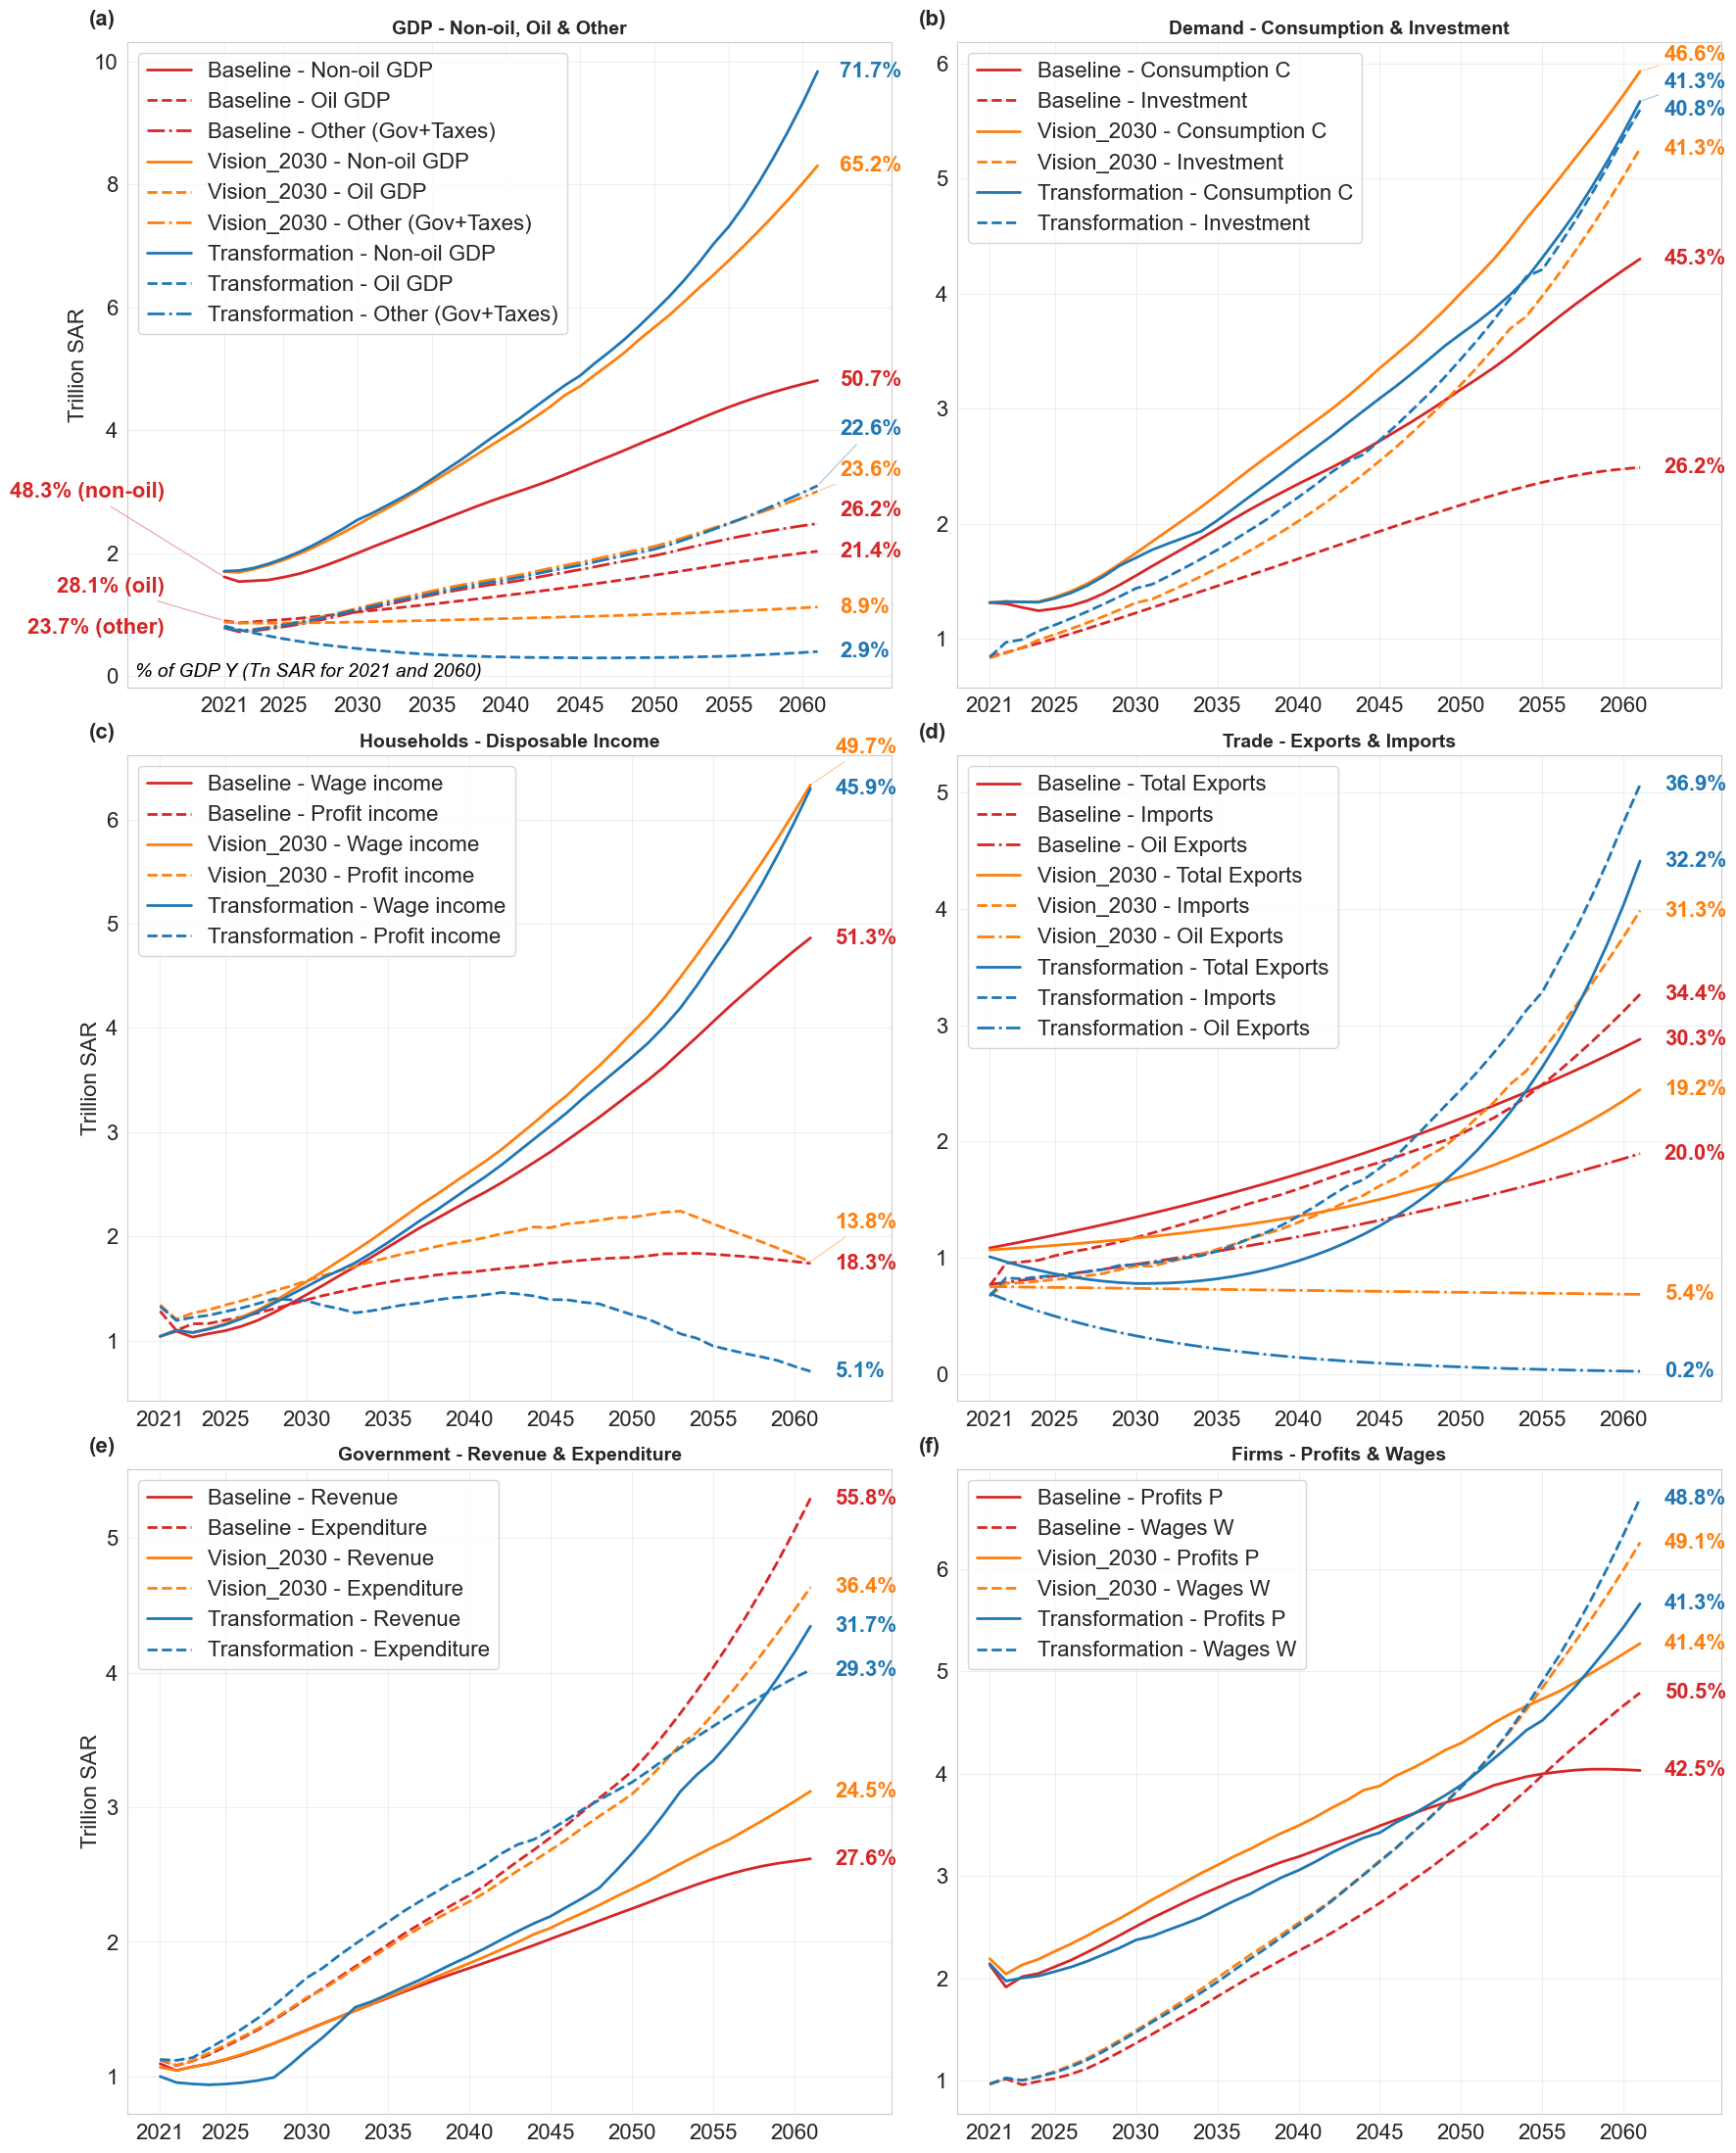

In [6]:
# Plot 2: Macro scenario comparison
# Six panels: Demand, Households, Trade, Government, Stocks, Firms
# Colour = scenario; solid line = first variable per panel, dashed = second variable
plot_macro_comparison(exp_reports)

## Financial and Real Stocks Comparison
Four-panel figure showing major balance-sheet stocks across scenarios:  
capital (nominal/real), household wealth & firm loans, government stocks, FDI stocks.

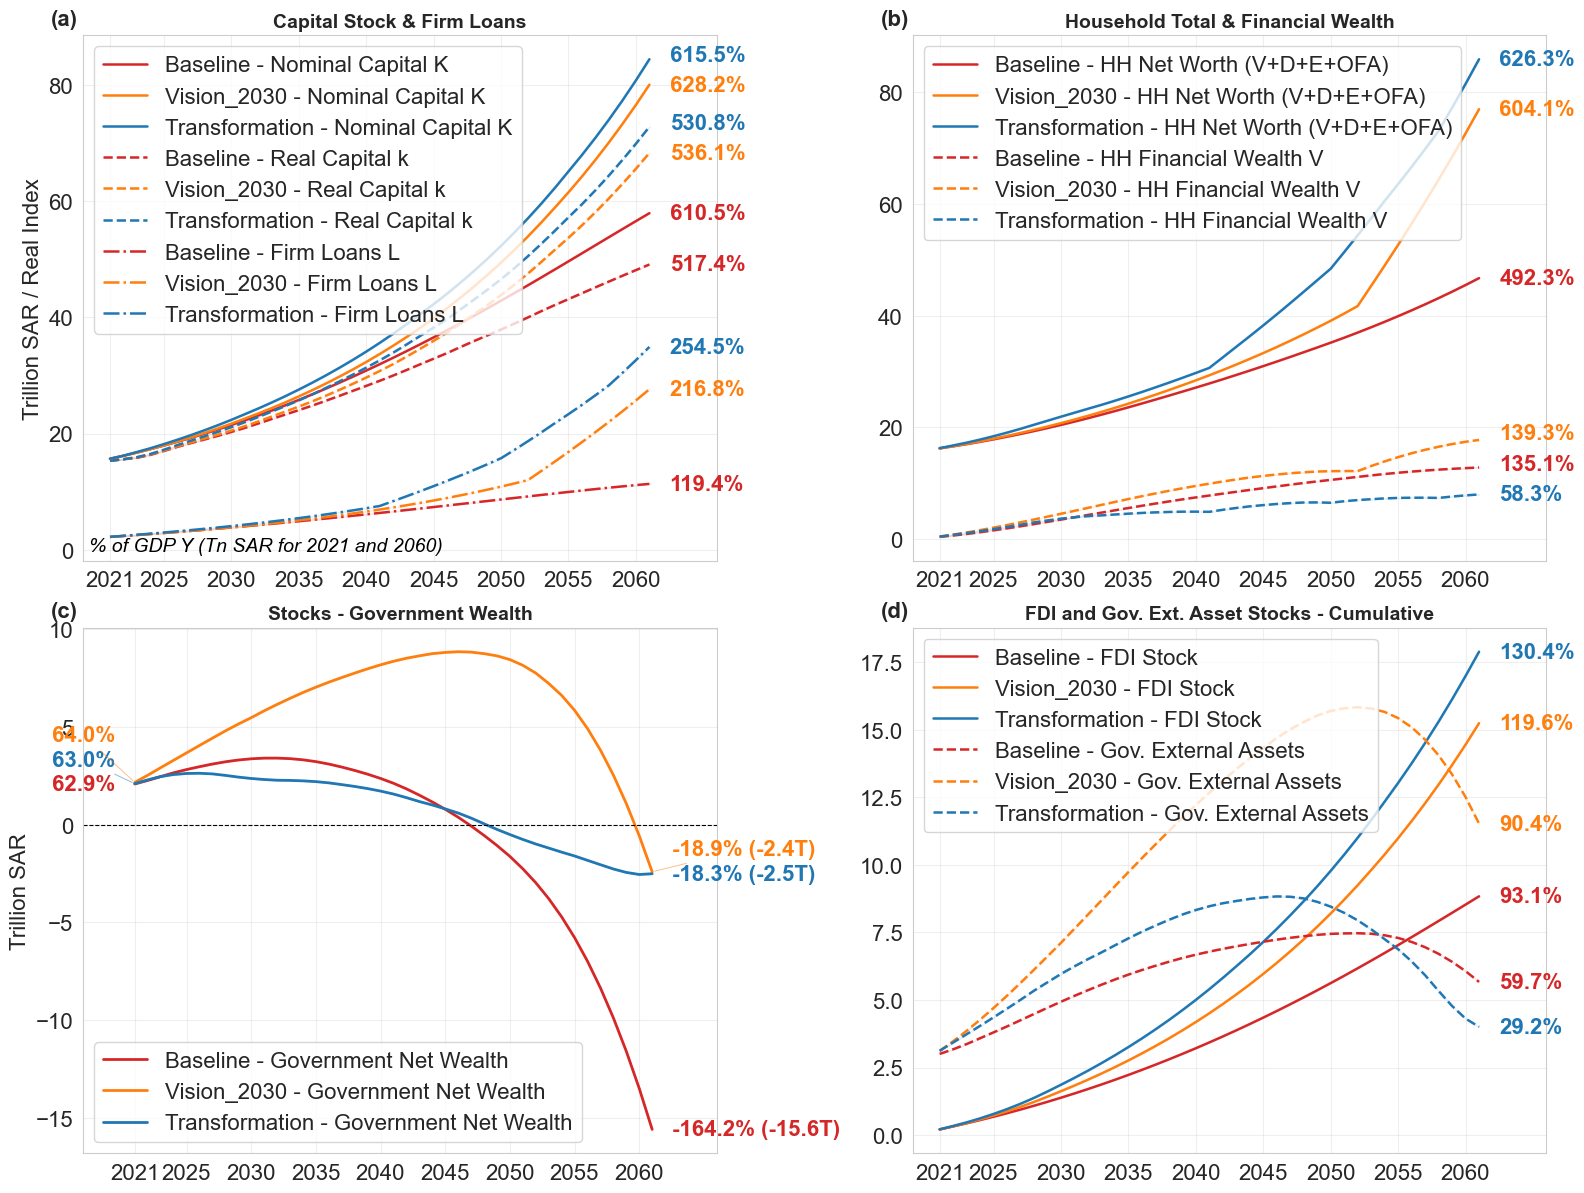

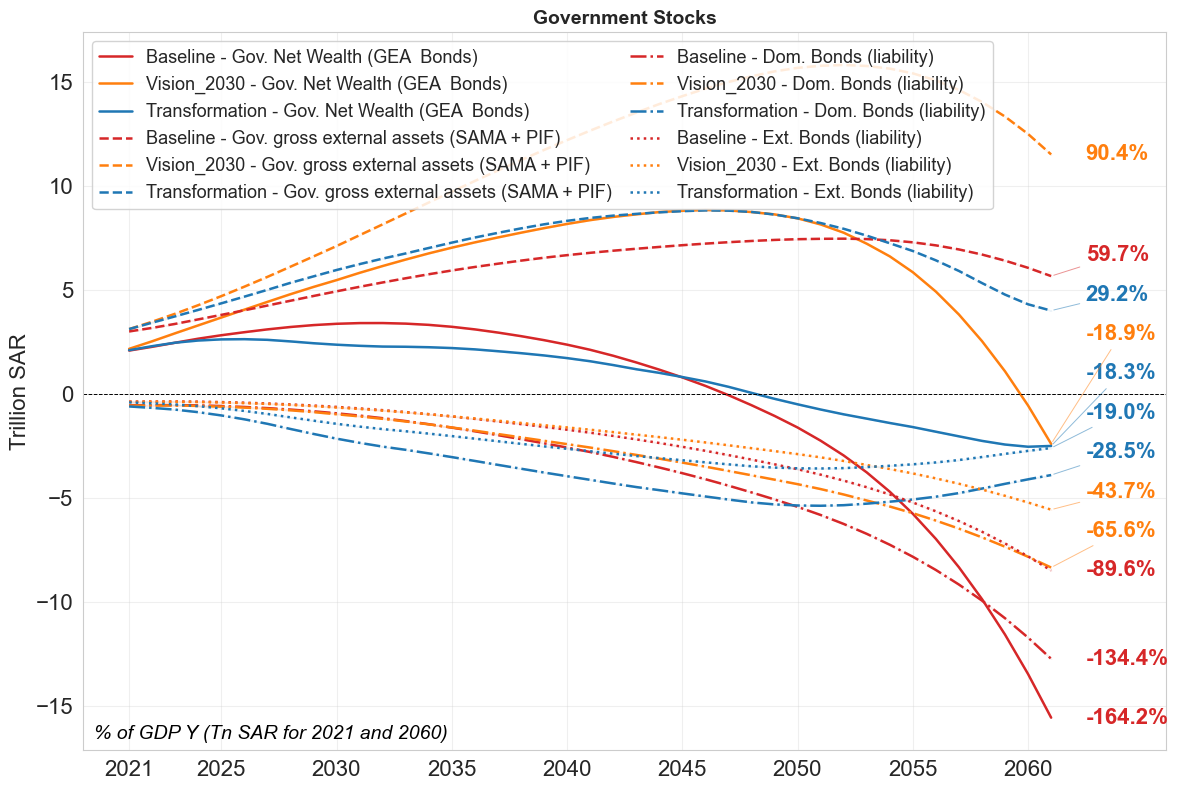

In [7]:
# Plot 4: Financial & Physical Stocks scenario comparison
# Six panels: Capital Stock, HH Wealth & Firm Loans, Government Stocks,
#             FDI Stocks, Energy Infrastructure (physical), Water Infrastructure
plot_stocks_comparison(exp_reports)

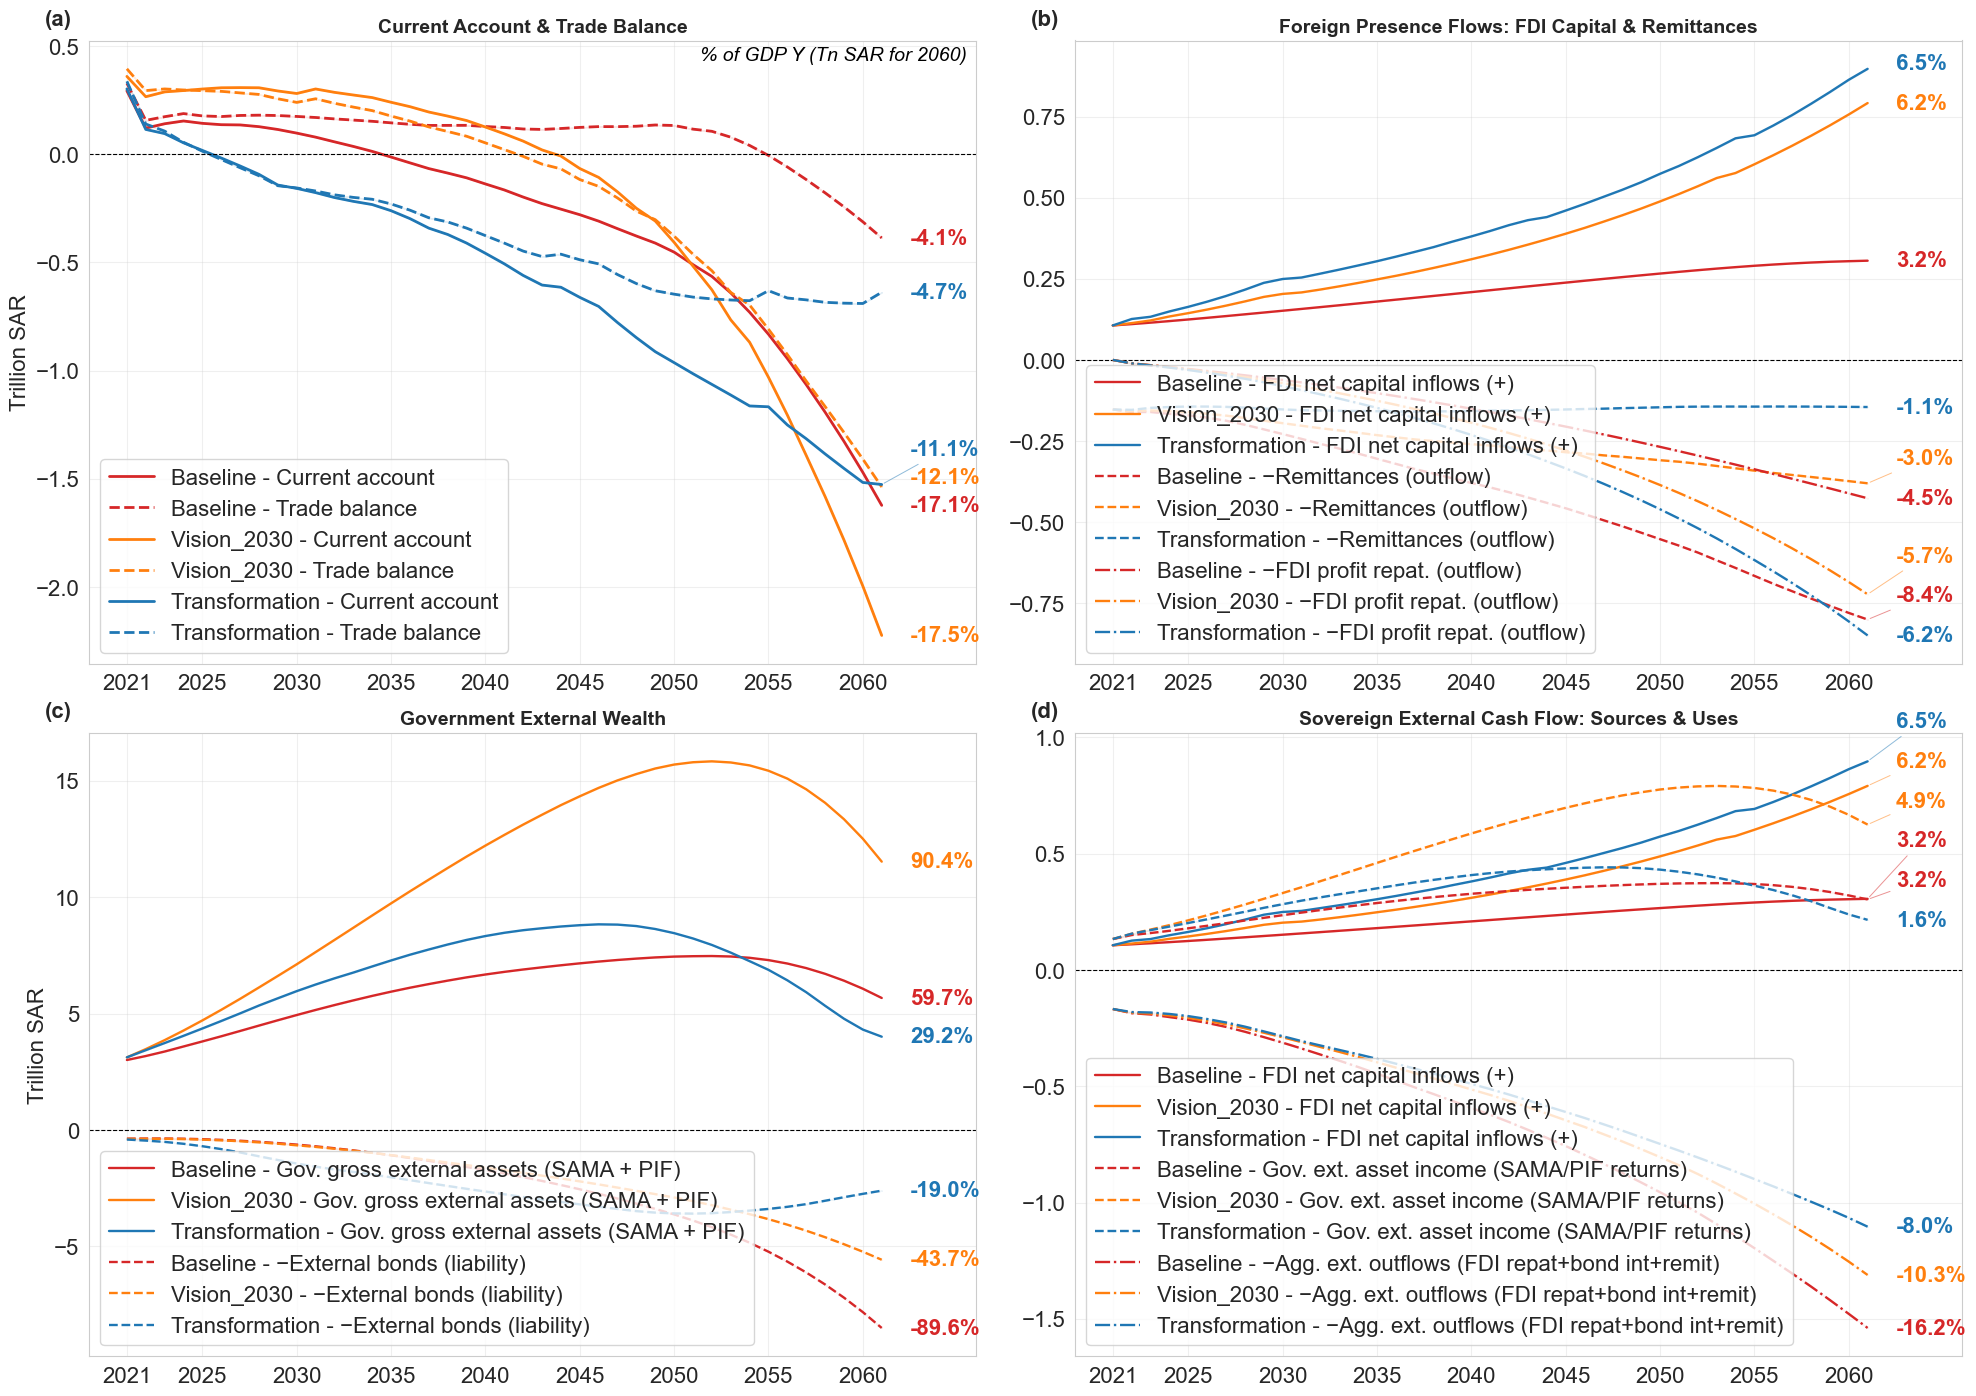

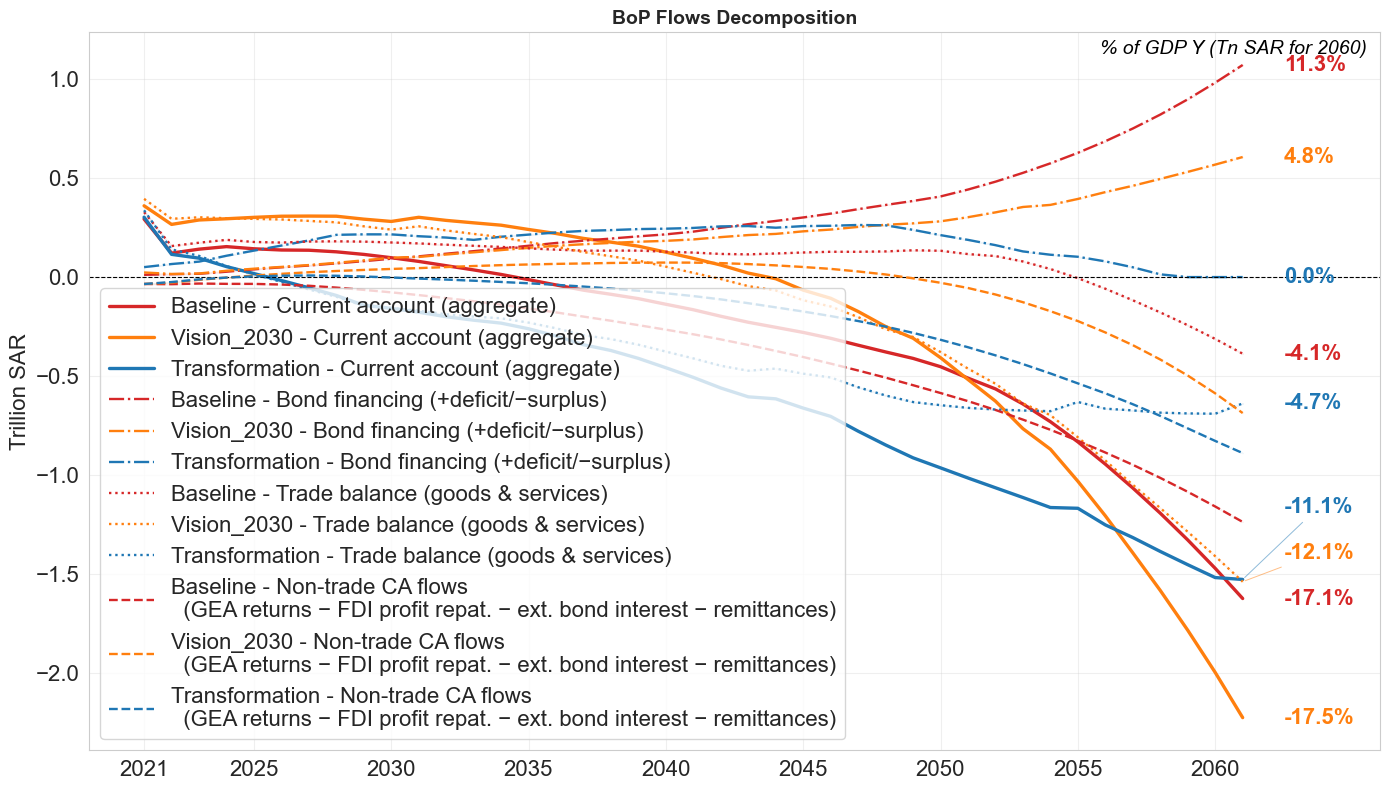

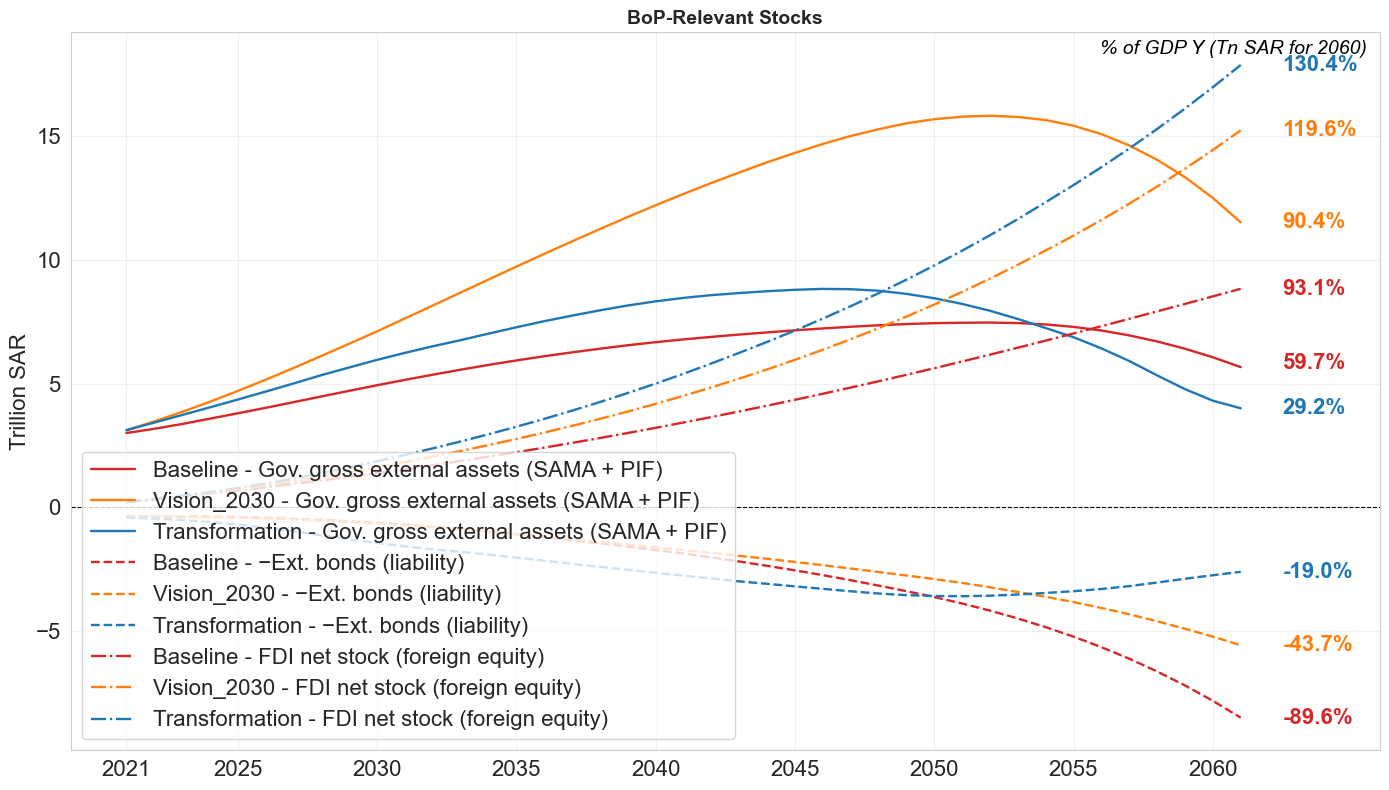

In [8]:
# Plot 3: Balance of Payments scenario comparison
# Four panels: Current Account & Trade Balance, FDI Net Inflows,
#              Government External Wealth (NFA), Remittances
# Colour = scenario; solid line = first variable per panel, dashed = second (where applicable)
plot_bop_comparison(exp_reports)

## Top Sectors by GDP Y — Scenario Comparison
Union of the top-5 sectors (by nominal GDP Y) at the start and end of the simulation period across all scenarios.  
One subplot per unique sector; colour = scenario.  ★start / ★end marks which scenarios ranked that sector in their top 5.

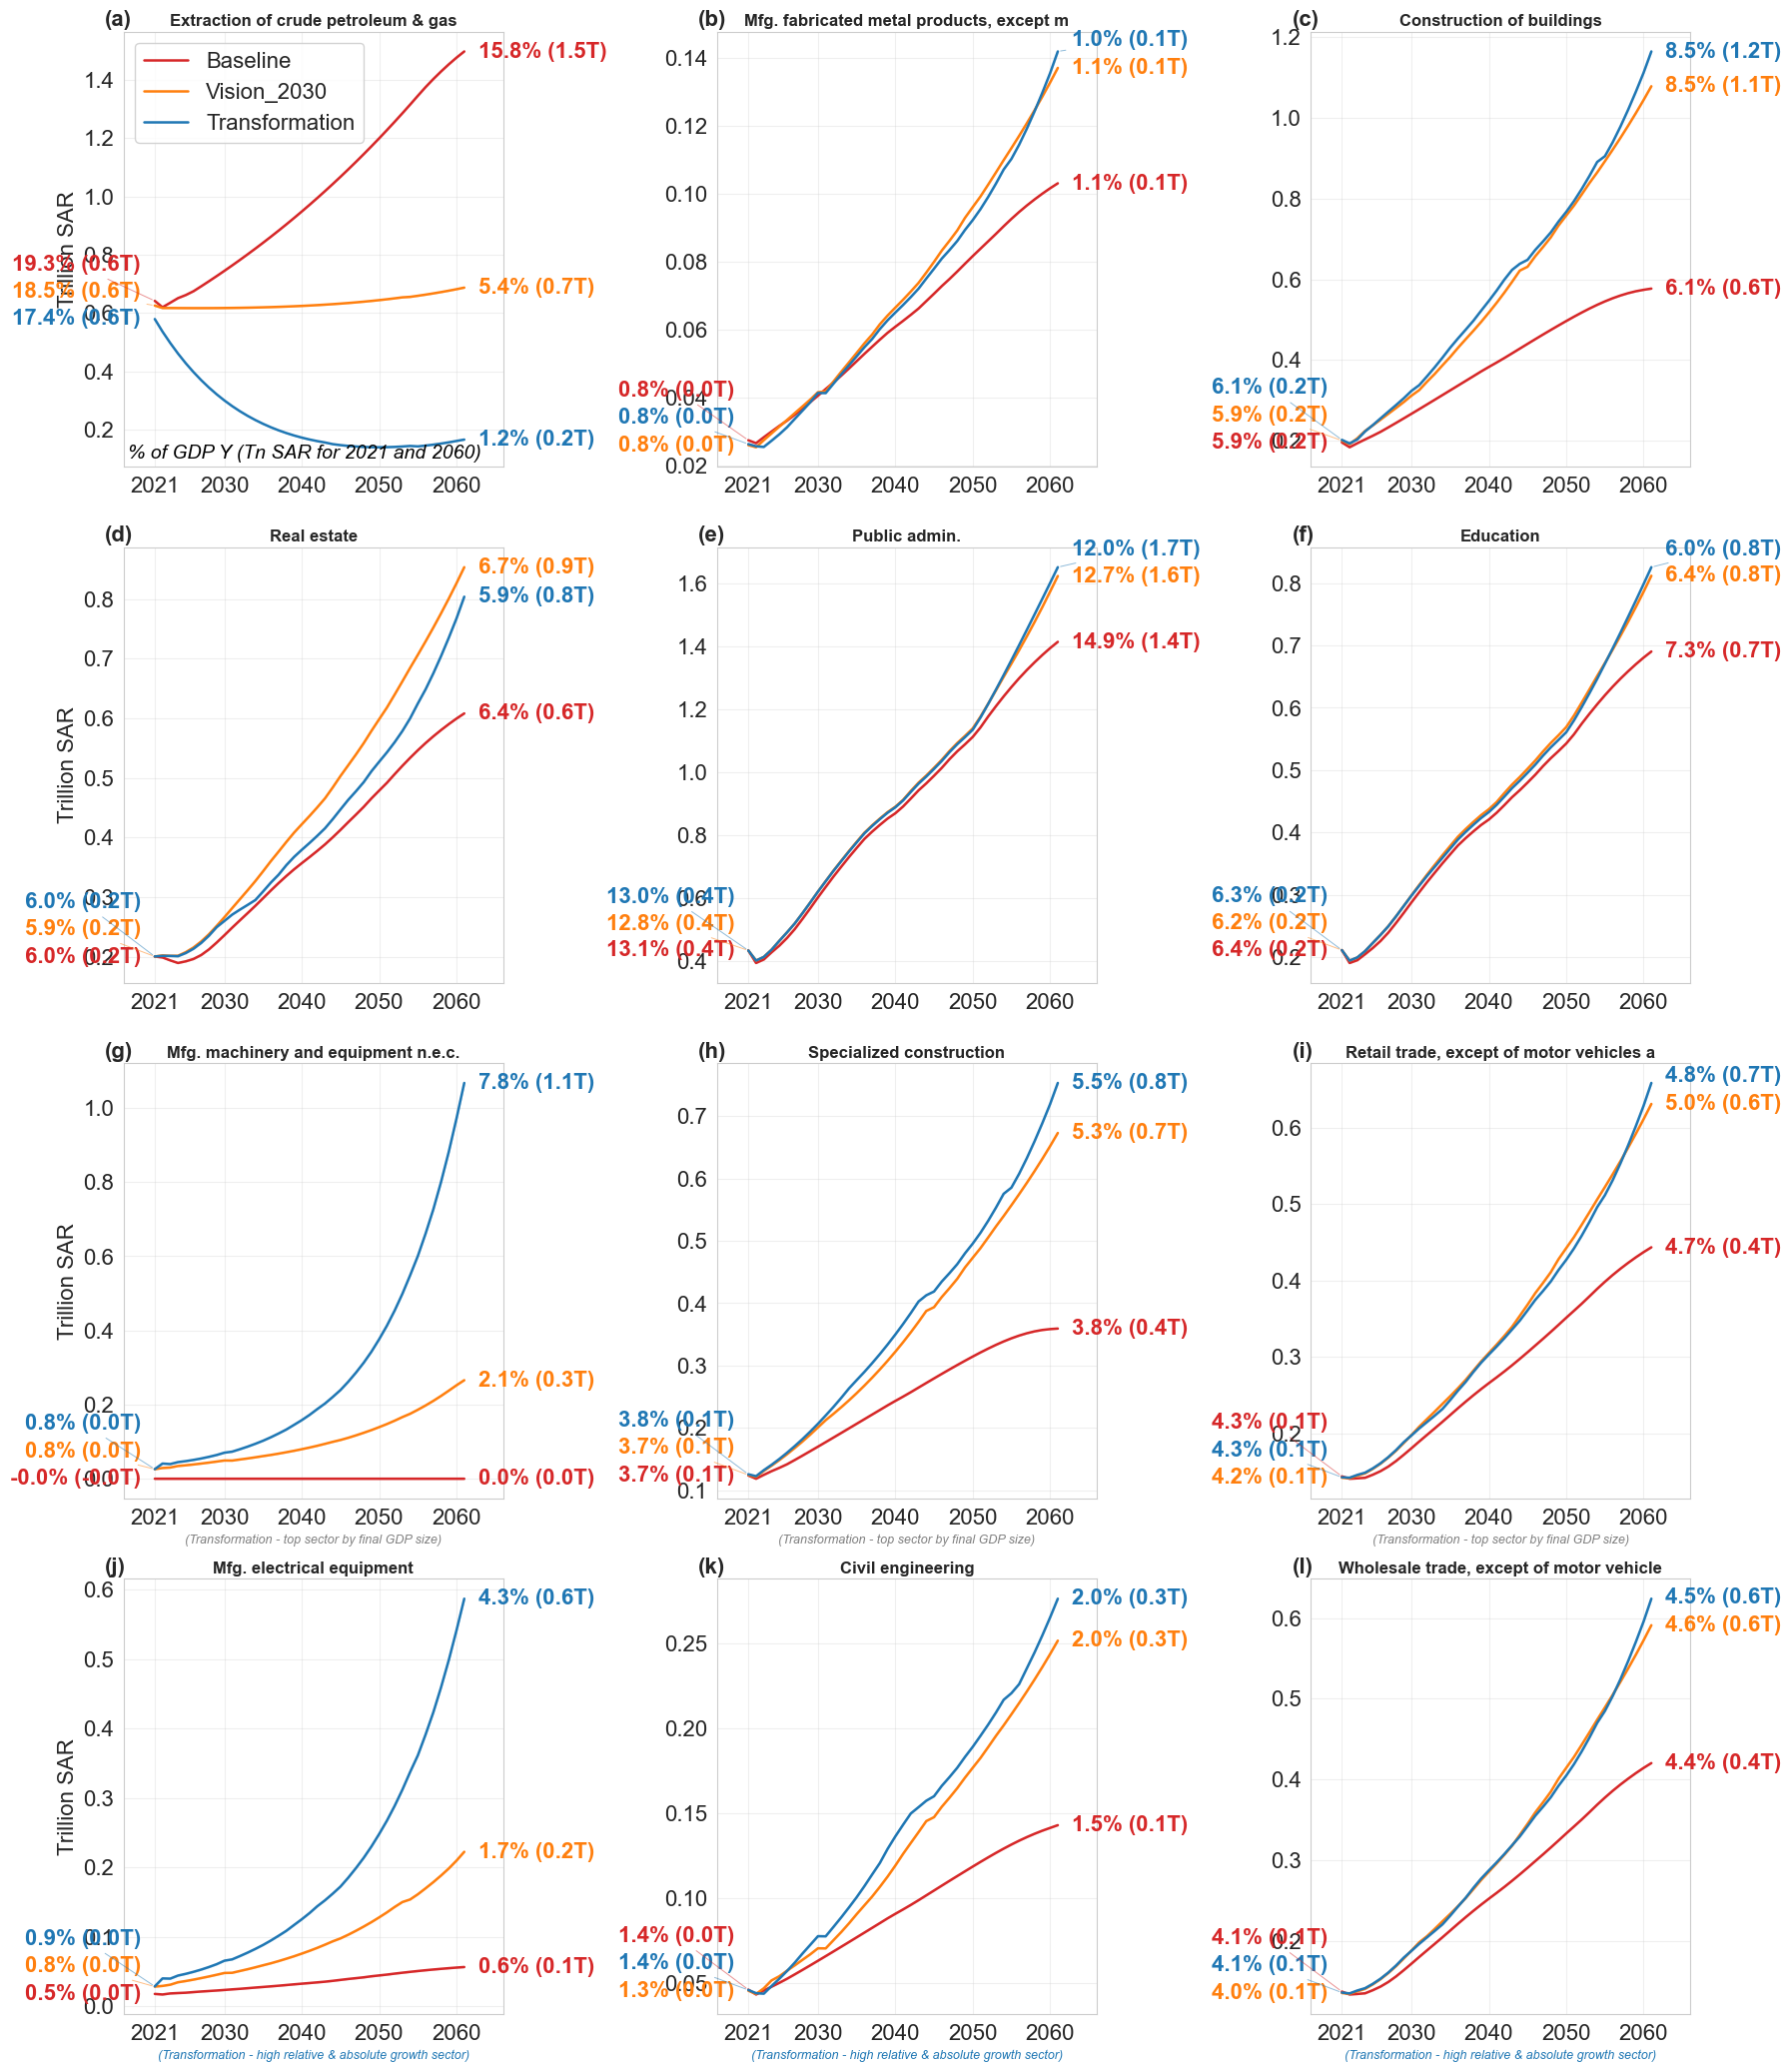

In [9]:
# Plot 5: Top sectors by GDP Y, scenario comparison
# Identifies top-5 sectors by nominal Y at start and end of simulation per scenario,
# takes the union across all scenarios, and plots one panel per unique sector.
plot_sectoral_gdp_comparison(exp_reports)

## Energy outcomes: Plots 

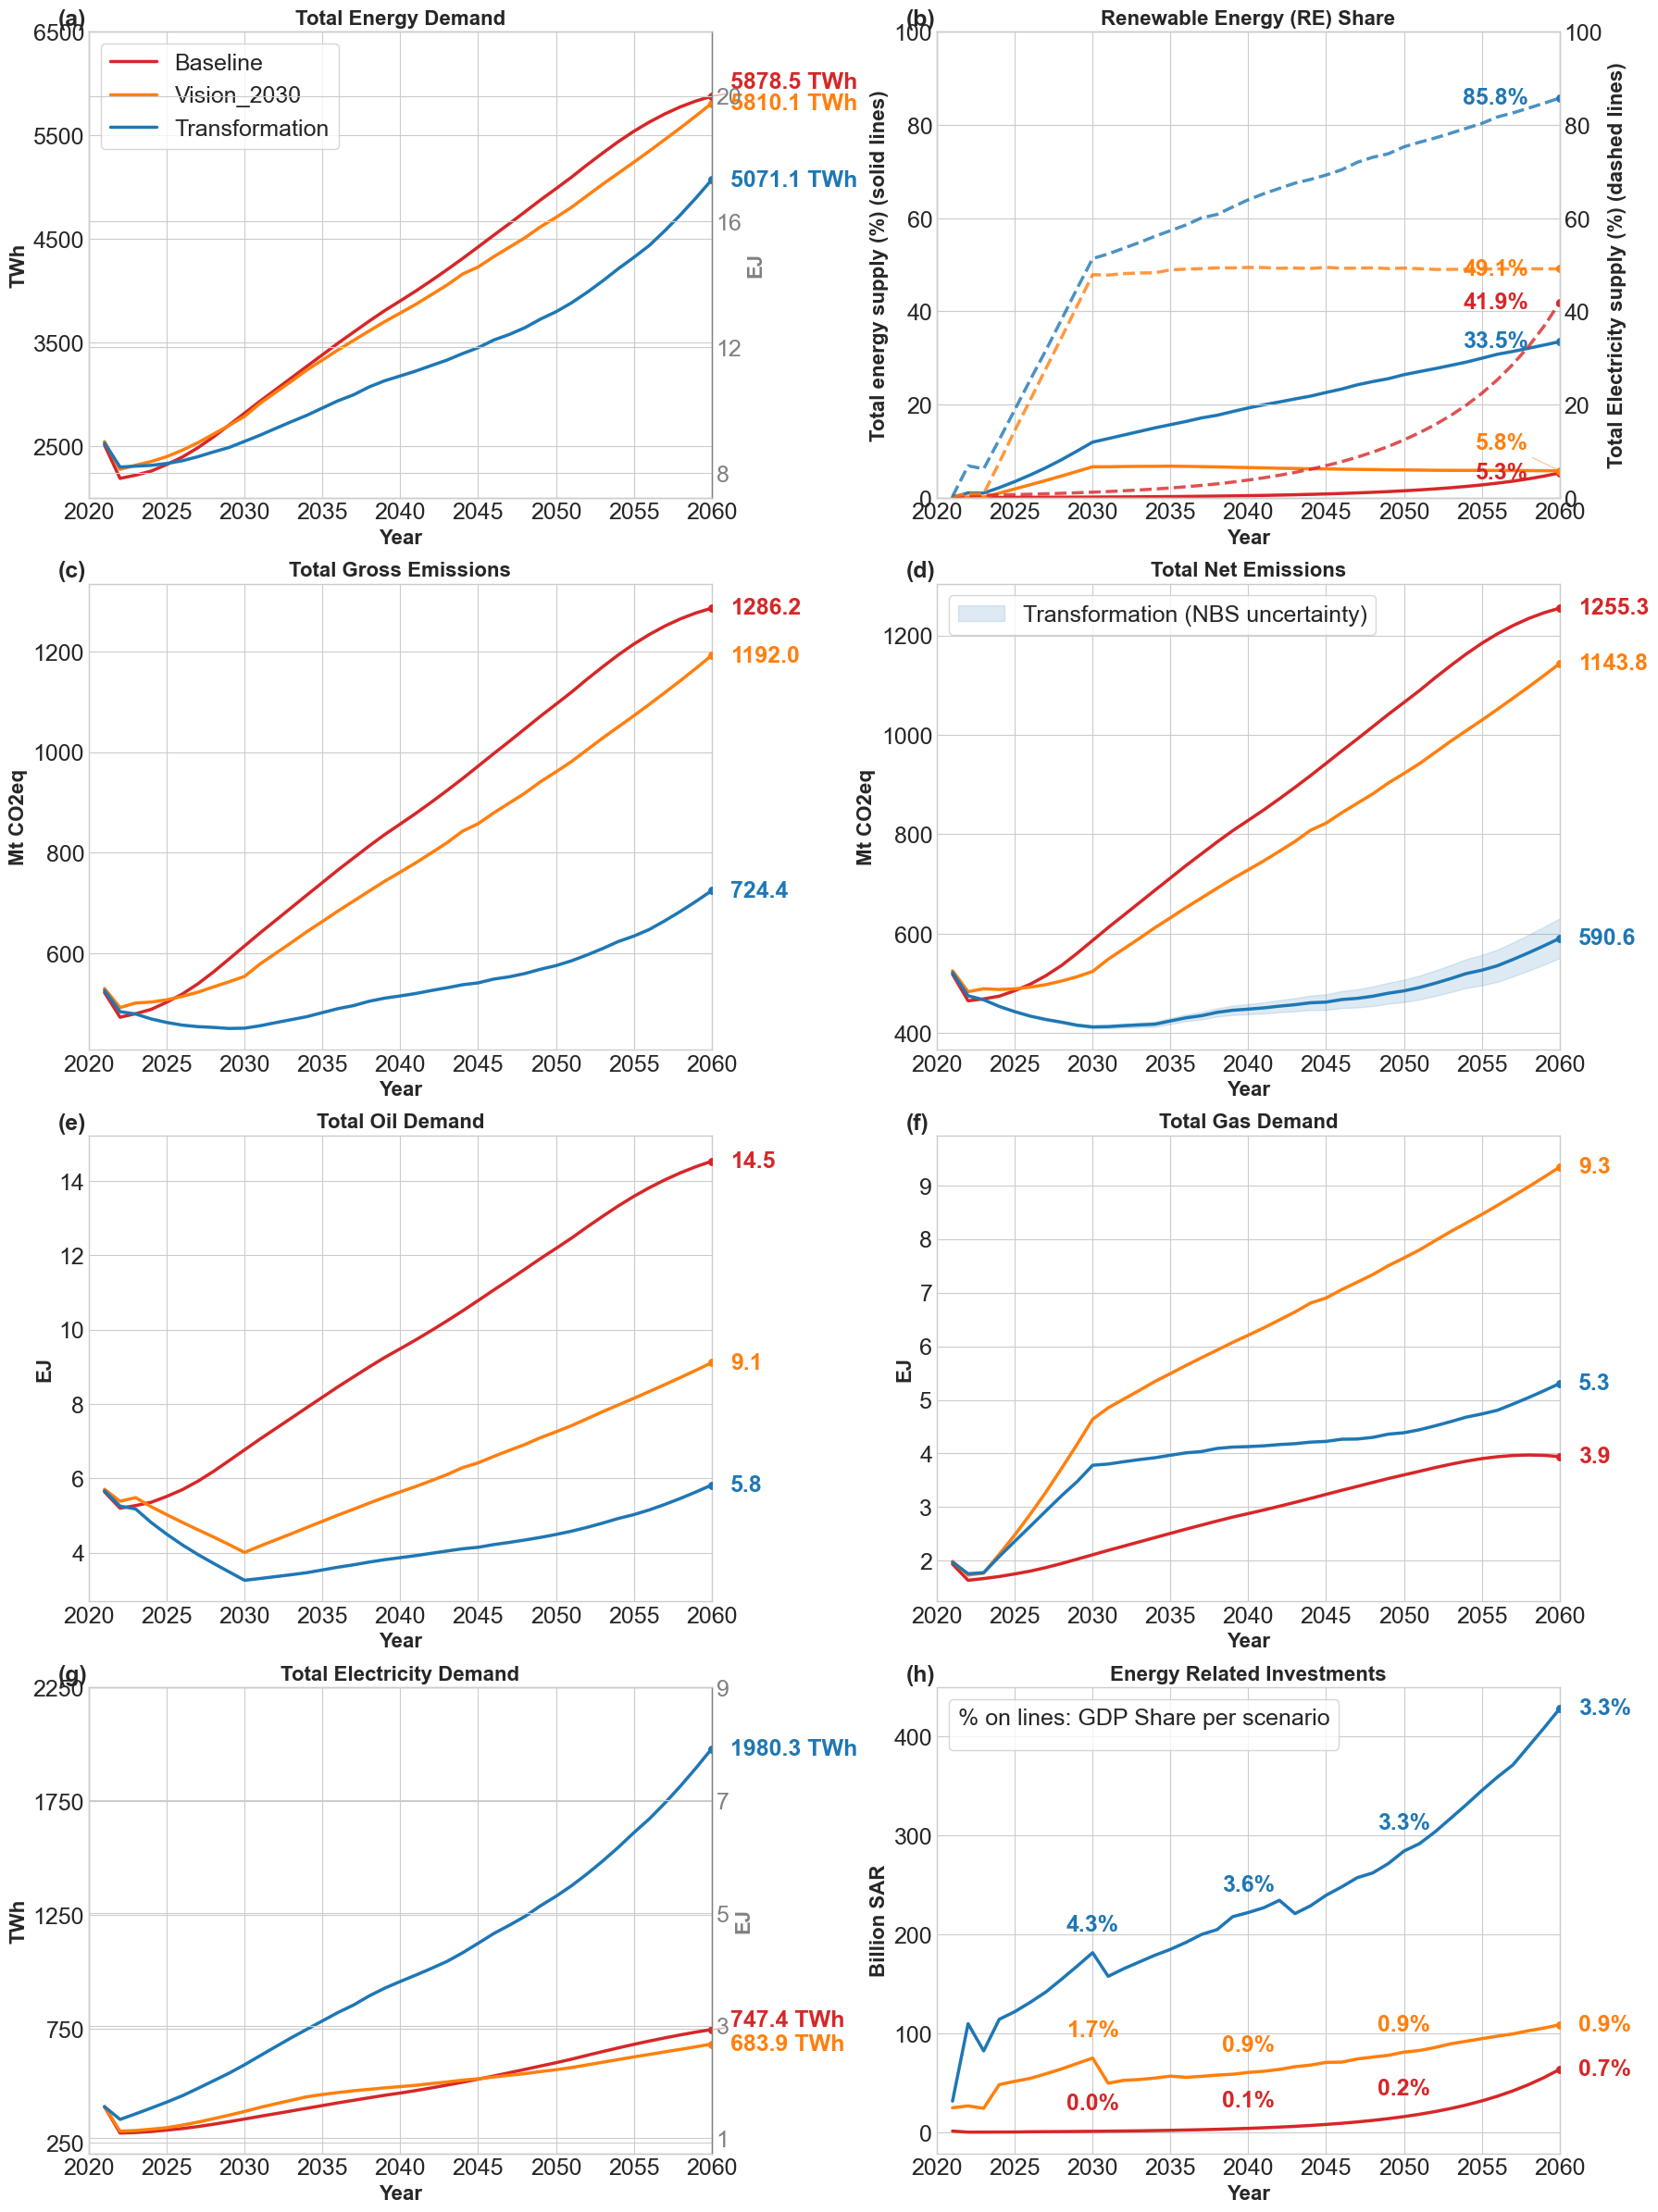

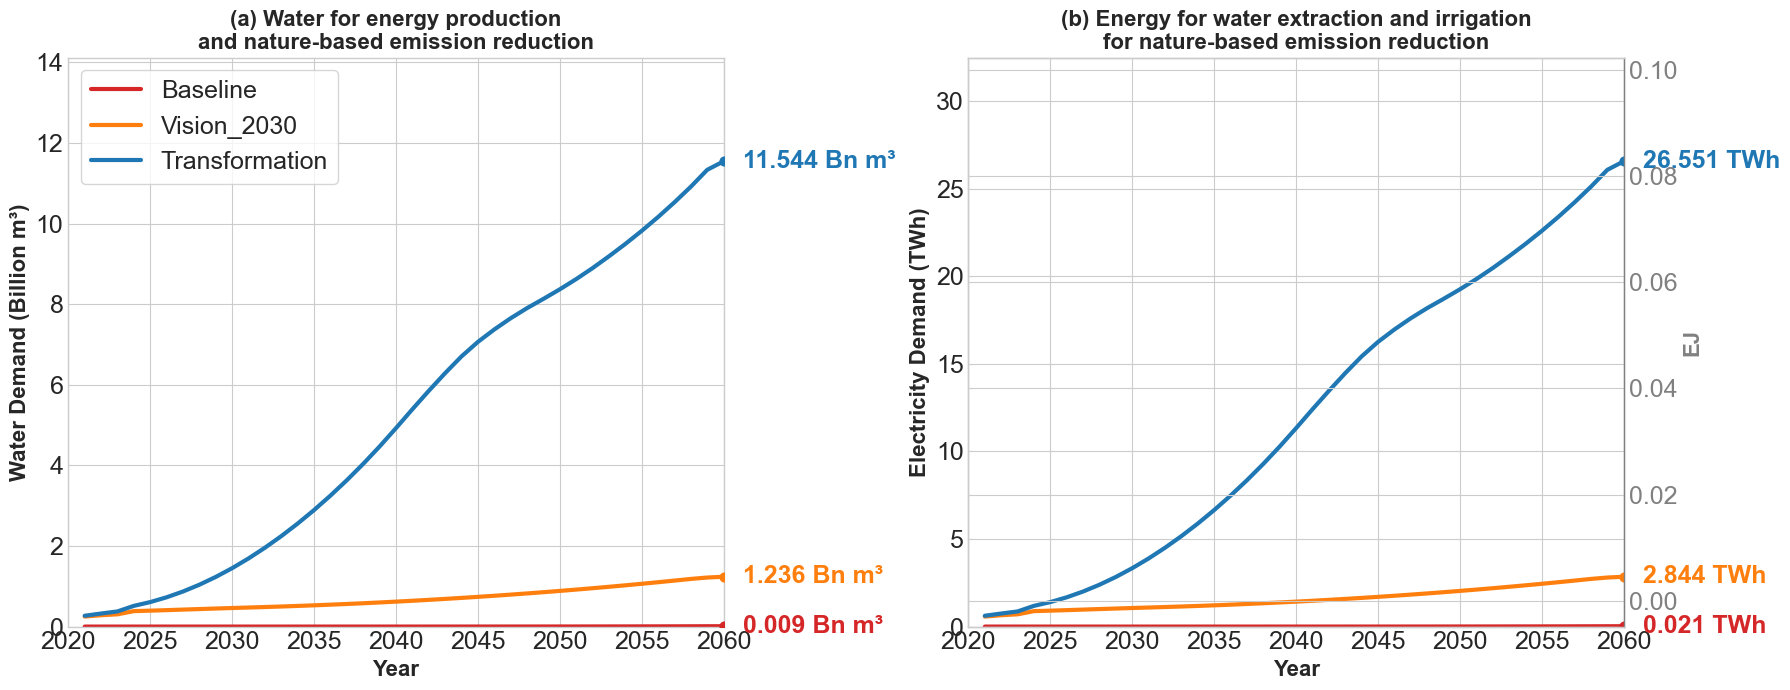

In [10]:
from model.postprocessing_energy import plot_energy_scenarios , plot_nexus_water_all_scenarios
plot_energy_scenarios(exp_reports)
plot_nexus_water_all_scenarios(exp_reports)

Starting Water Results Generation...
>> Running simulation 1/3 (Baseline, seed=552378)                   v.Y_growth_rate_forecast[t] 0.19050854100449066 time  1
v.Y_growth_rate_forecast[t] 0.26816194169624863 time  2
v.Y_growth_rate_forecast[t] 0.06671226465715482 time  3
v.Y_growth_rate_forecast[t] 0.06730402252102109 time  4
v.Y_growth_rate_forecast[t] 0.06445246467464141 time  5
v.Y_growth_rate_forecast[t] 0.06449069413624986 time  6
v.Y_growth_rate_forecast[t] 0.07011455342794724 time  7
v.Y_growth_rate_forecast[t] 0.06754671737440383 time  8
v.Y_growth_rate_forecast[t] 0.0639284004255894 time  9
v.Y_growth_rate_forecast[t] 0.06650227574060281 time  10
v.Y_growth_rate_forecast[t] 0.0668612638605465 time  11
v.Y_growth_rate_forecast[t] 0.06315805148065798 time  12
v.Y_growth_rate_forecast[t] 0.05830403775626075 time  13
v.Y_growth_rate_forecast[t] 0.05222539814090548 time  14
v.Y_growth_rate_forecast[t] 0.04942820783235637 time  15
v.Y_growth_rate_forecast[t] 0.04720379055907627 tim

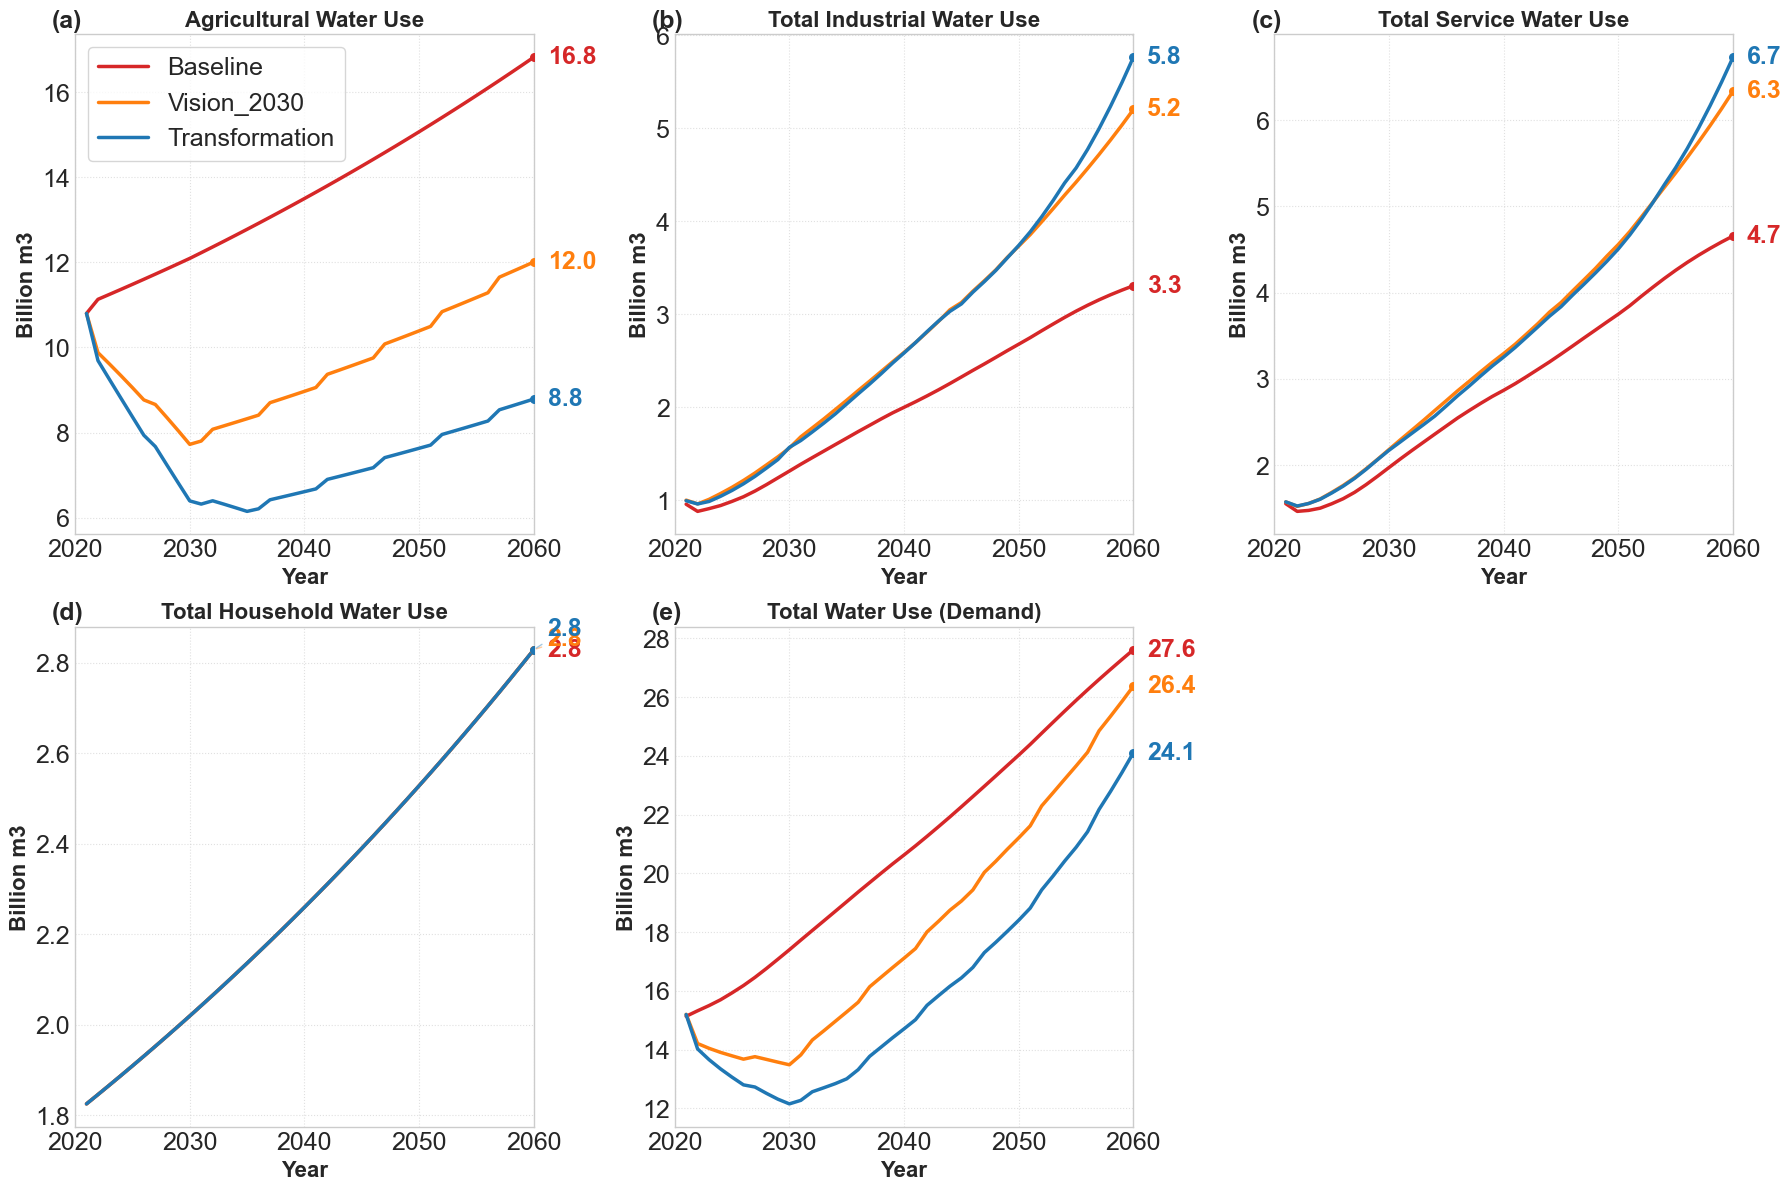

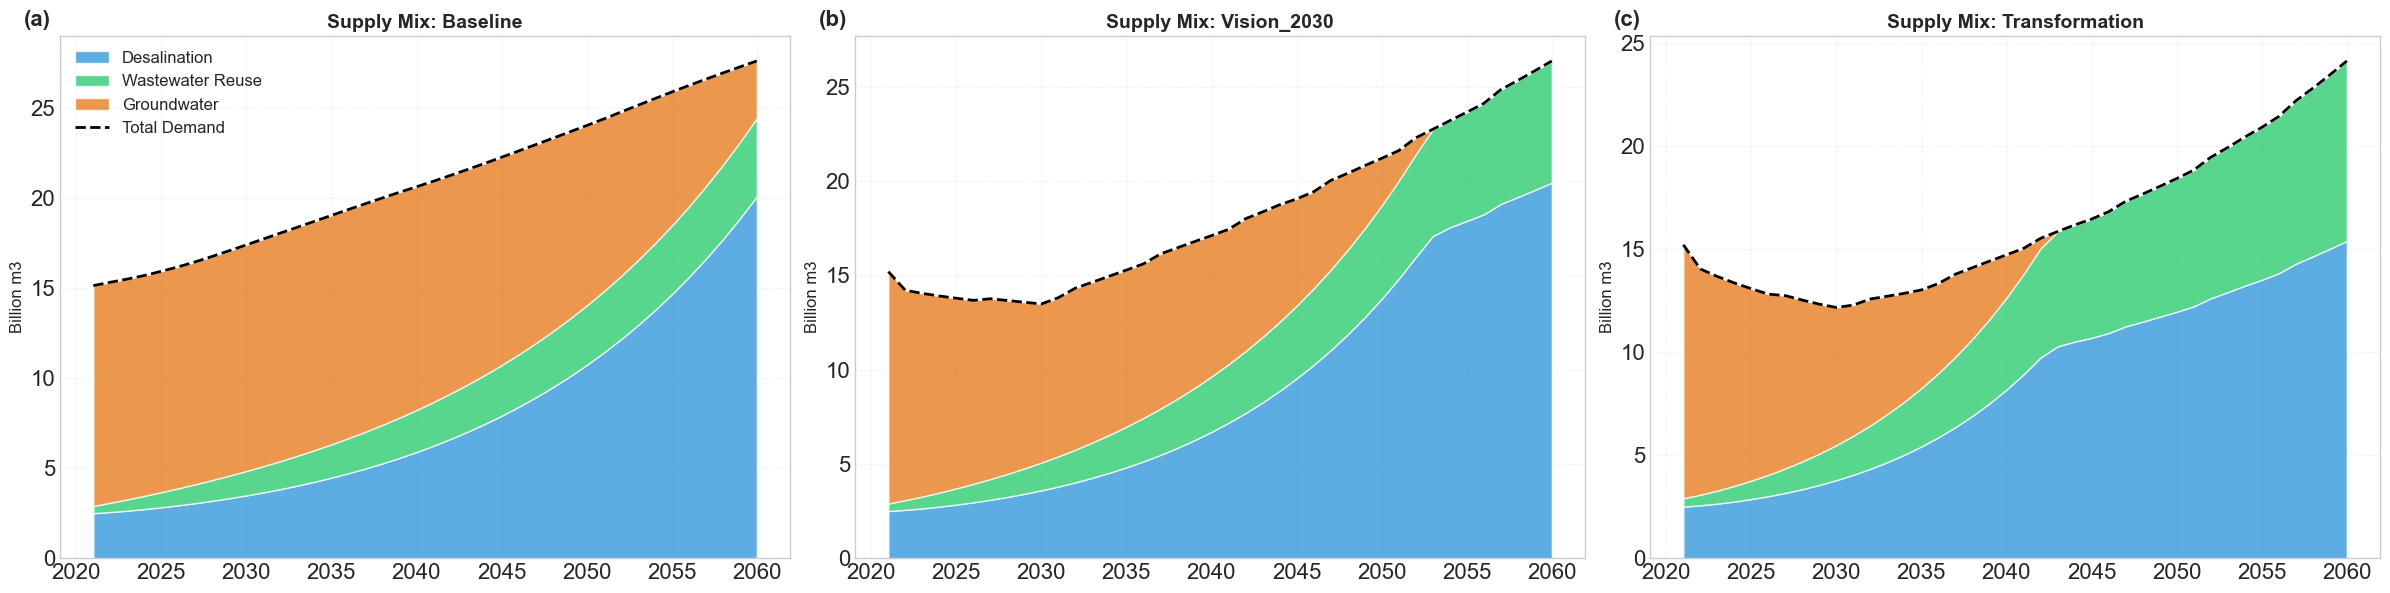

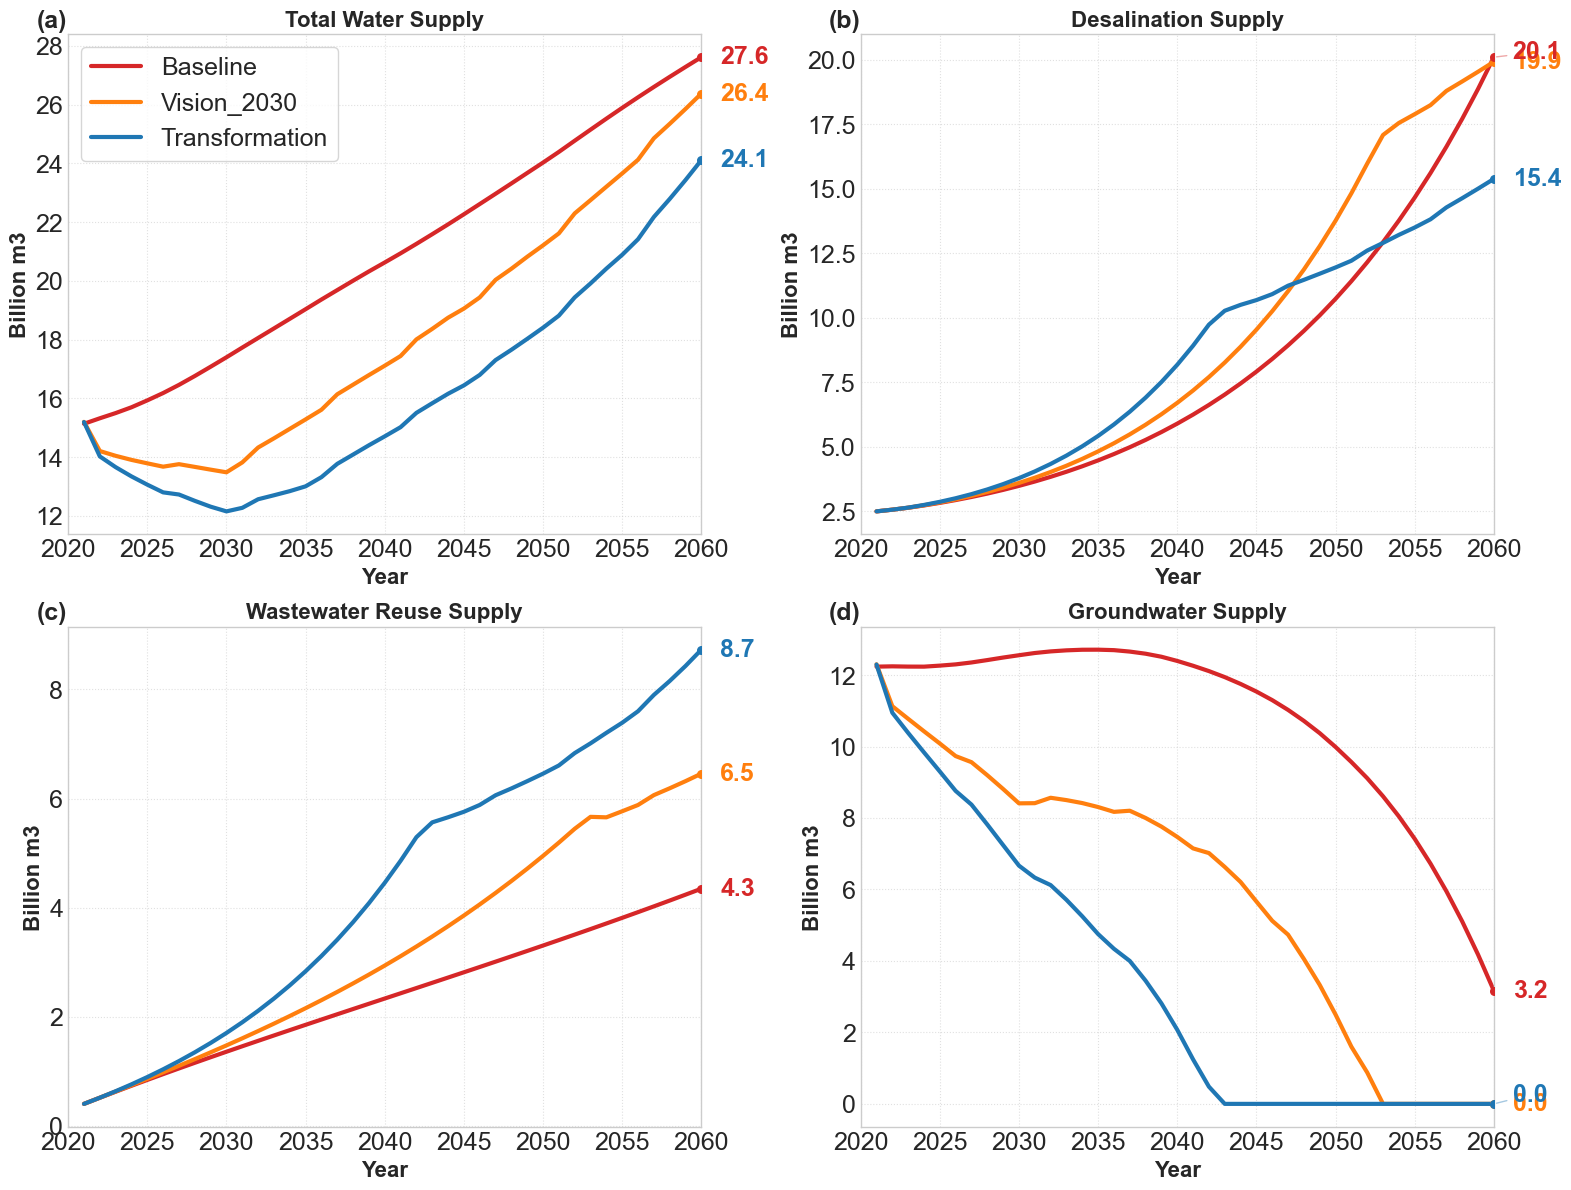

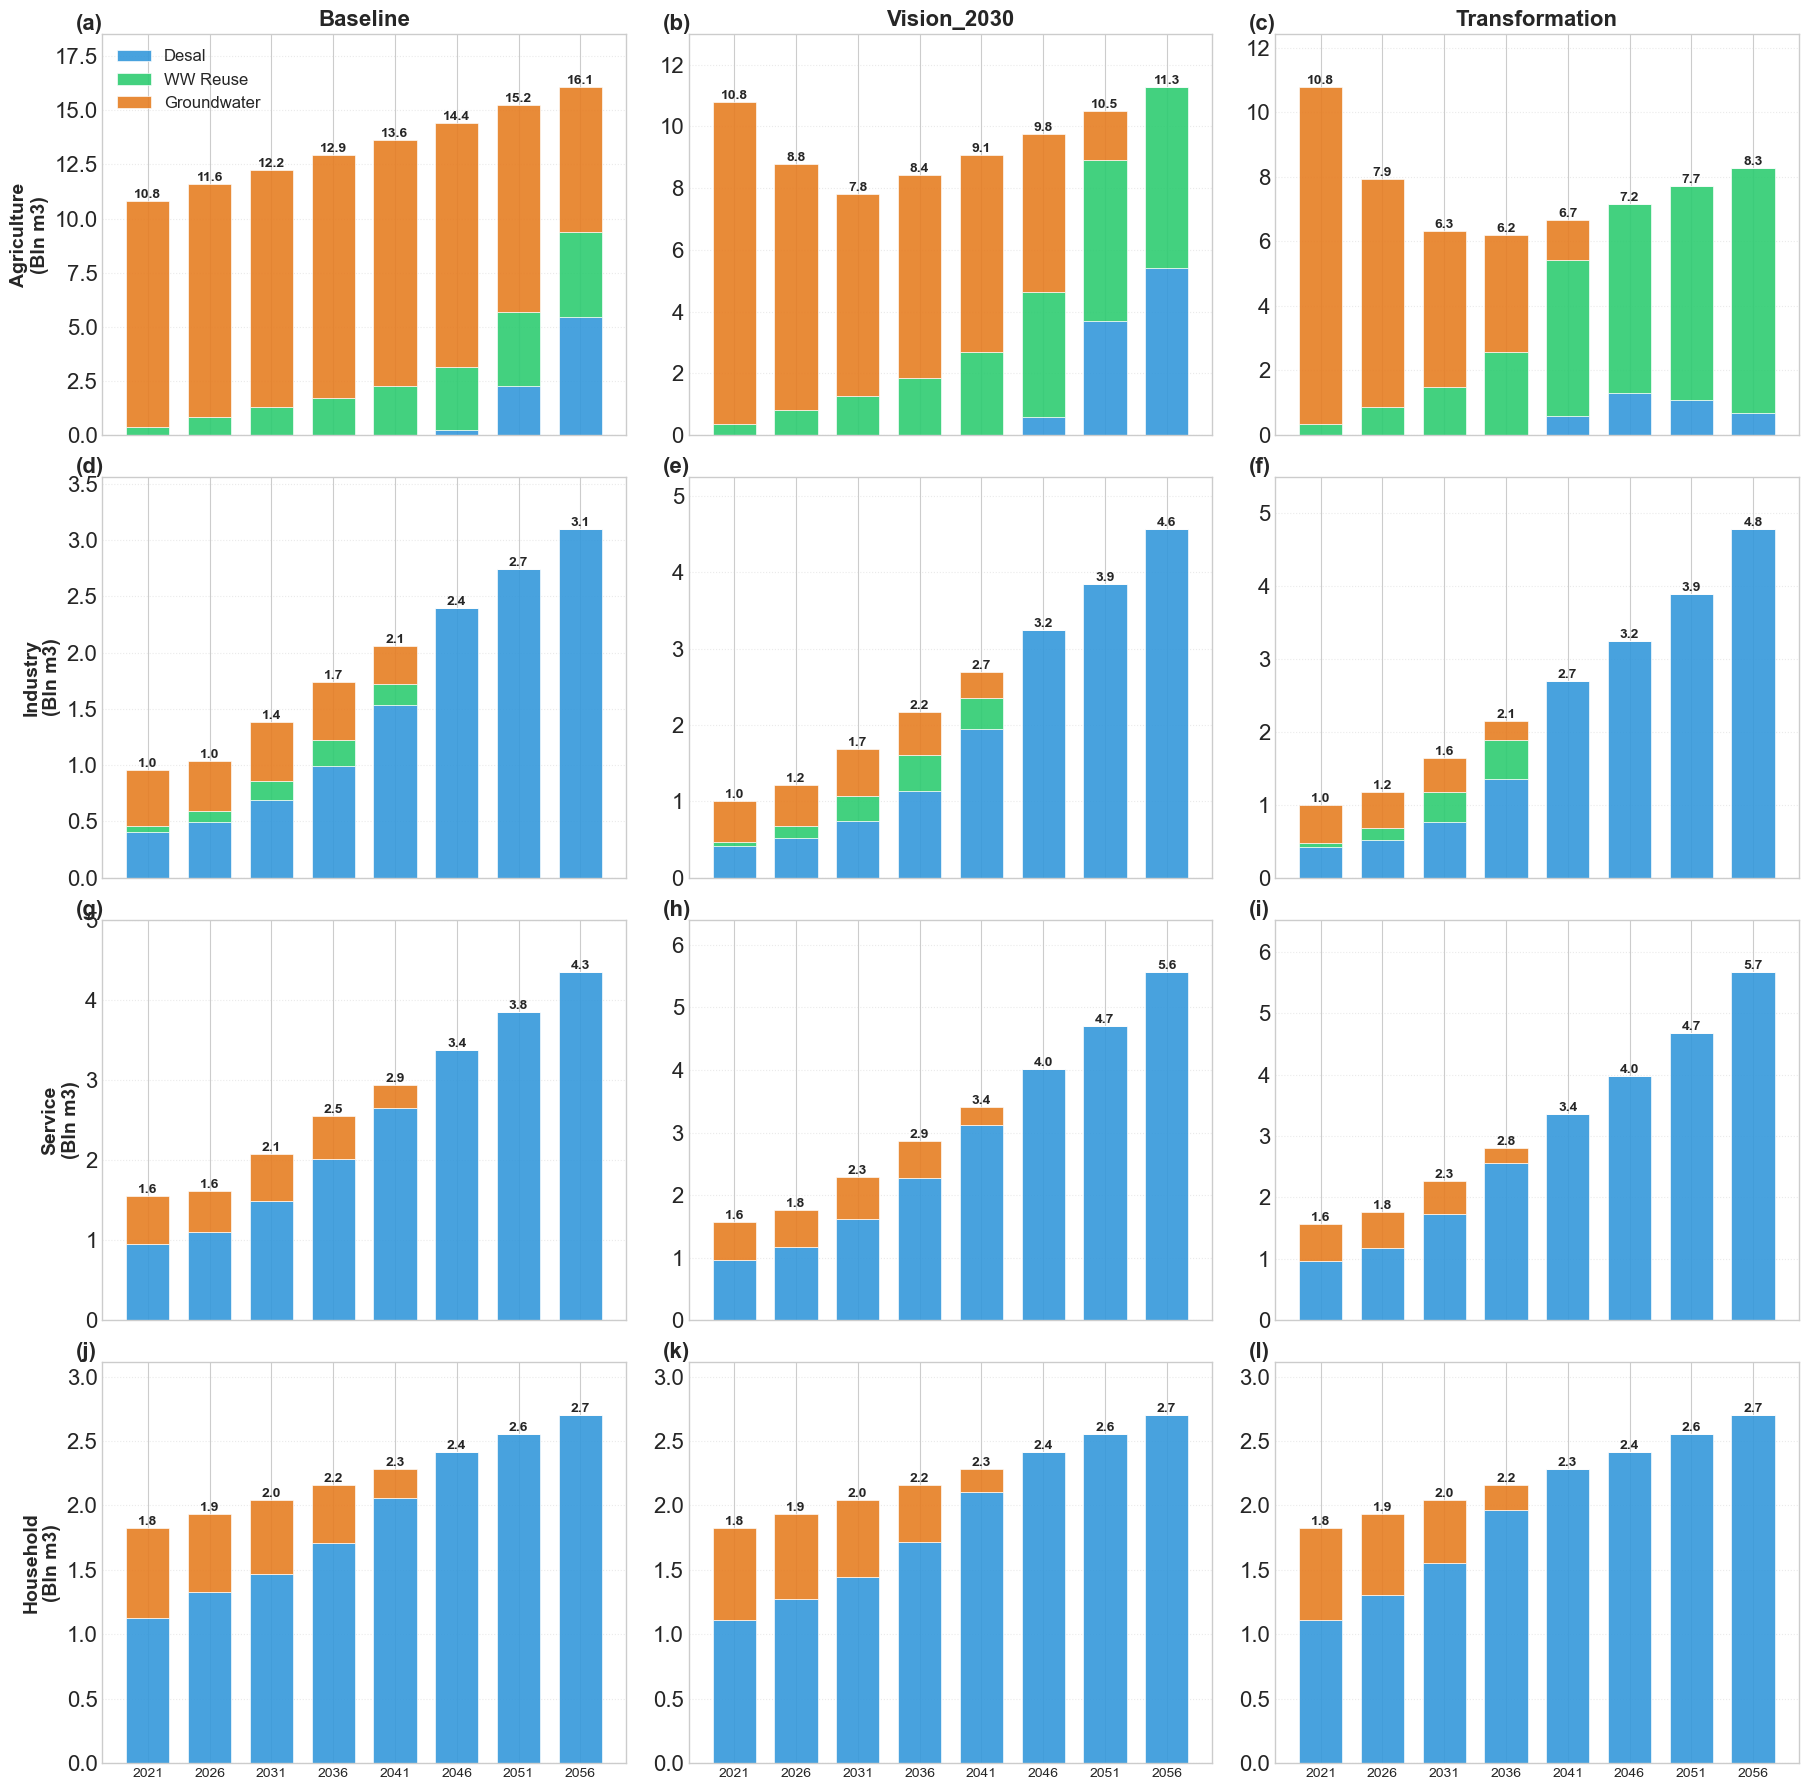

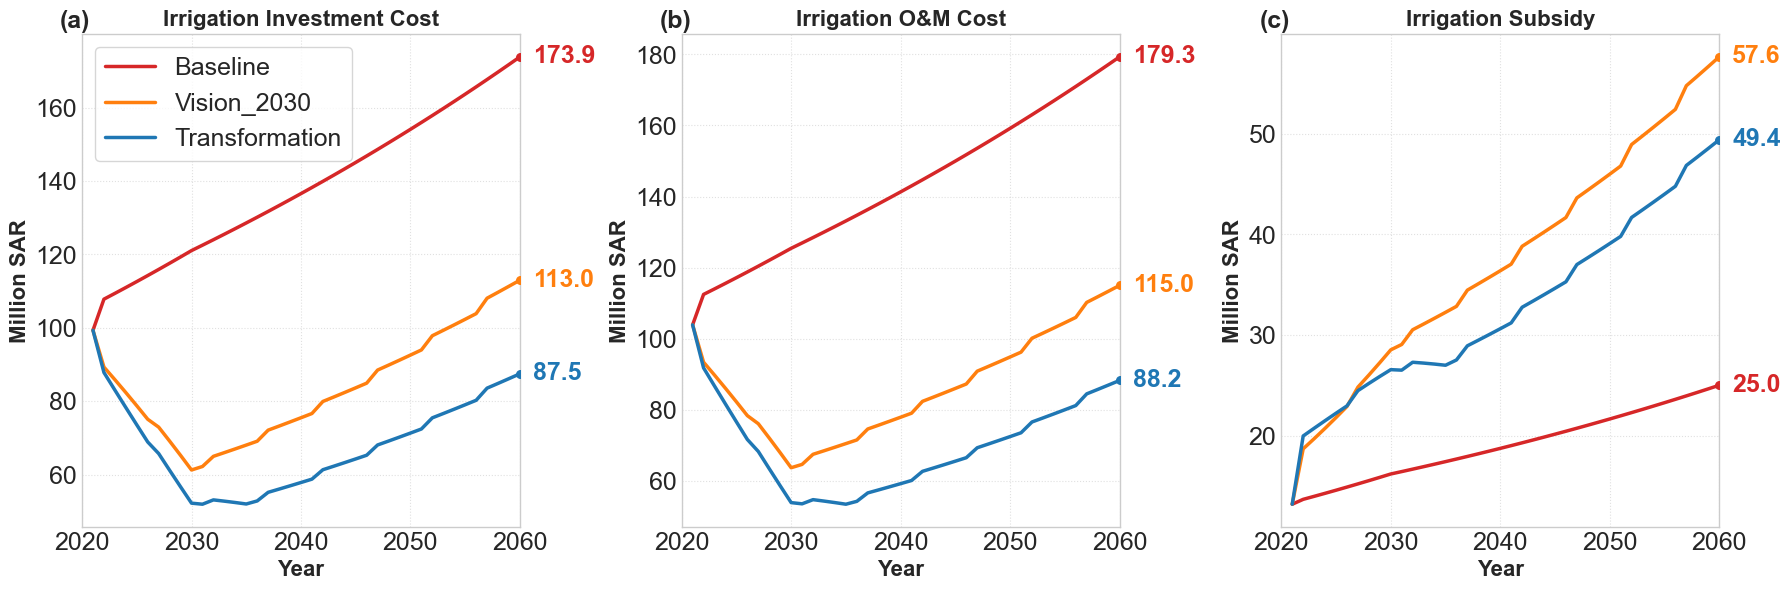


All water resource results have been generated successfully.


In [11]:
from model.plot_water_results import plot_water_results
plot_water_results ()

## Saving model results locally

In [12]:
# If you want to save results to a file for later analysis
# Important: these are ignored by git and will only be on your local machine
import datetime
import pickle
now = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f'saved_results/results_{now}.pkl', 'wb') as file:
    pickle.dump(exp_reports, file)

In [13]:
# If you want to load previously saved results
# Set this to true if you want to load previous results
load_results = False
if load_results:
    filename = "enter_filename_here"  # e.g., 'results_20260106_120423.pkl'
    with open(f'saved_results/{filename}', 'rb') as f:
        revived_results = pickle.load(f)
    print(f"Loaded {len(revived_results)} experiment reports.")

## Authorship of model components and paper sections

Michael Miess (all model components and paper sections): Conceptualization (including methodology of the model), data curation, formal analysis, investigation, methodology, software (model architecture and code), supervision, validation, visualization, writing – original draft, writing – review and editing. 

Ansir Ilyas (focus on energy model components and paper sections): Conceptualization, data curation, formal analysis, investigation, software (model code), validation, visualization, writing – original draft, writing – review and editing. 

Dan Wang (focus on water model components and paper sections): Conceptualization, data curation, formal analysis, investigation, software (model code), validation, visualization, writing – original draft, writing – review and editing. 

Asjad Naqvi: Conceptualization, methodology, investigation, validation, writing – review and editing. 

Yoshihide Wada: Conceptualization (including initial conception of the project and study), funding acquisition, project administration, resources, supervision, investigation, validation, writing – review and editing.